# Onboarding Task: Computational Modelling & Optimisation for Organ-on-Chip Systems

**Objective:** Build a coupled pharmacokinetic–toxicity model, fit it to synthetic data, interrogate the fit with sensitivity analysis, and accelerate the pipeline with machine learning surrogates.

**Prerequisites:** Read the accompanying *Background Document* (`onboarding_background.pdf`). This notebook assumes you have done so and will not re-derive the equations — only reference them.

**Structure:**
1. The Forward Model: Two-Compartment PK
2. Coupling a Second Model: Toxicity Response
3. Parameter Estimation: Local Methods
4. Parameter Estimation: Global Methods
5. Sensitivity Analysis
6. Parameter Identifiability & the Fisher Information Matrix
7. ML Surrogates and Hybrid Modelling

Each section contains:
- A brief recap of the relevant theory
- Guided implementation tasks with `# YOUR CODE HERE` stubs
- Verification cells that check your implementation

---

## Setup: Imports and Utilities

Run this cell to import all required libraries.

In [309]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from scipy.integrate import solve_ivp
from scipy.optimize import minimize, least_squares, differential_evolution, basinhopping
from scipy.interpolate import interp1d
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11})
plt.style.use('seaborn-v0_8-darkgrid')
%config InlineBackend.figure_format = 'retina'

print("All imports successful.")

All imports successful.


---
## Section 1 — The Forward Model: Two-Compartment PK

### Recap
The two-compartment PK model tracks drug concentration in a central compartment (blood, $C_1$) and a peripheral compartment (tissue, $C_2$):

$$\frac{dC_1}{dt} = -(k_{12} + k_e) \, C_1 + \frac{V_2}{V_1} \, k_{21} \, C_2$$

$$\frac{dC_2}{dt} = \frac{V_1}{V_2} \, k_{12} \, C_1 - k_{21} \, C_2$$

**Initial conditions** (IV bolus of dose $D$): $C_1(0) = D / V_1$, $C_2(0) = 0$.

### Task 1.1 — Implement the PK ODE system

Write a function `pk_rhs(t, y, params)` that returns $[dC_1/dt, \; dC_2/dt]$.

The `params` dictionary will contain keys: `'k12'`, `'k21'`, `'ke'`, `'V1'`, `'V2'`.

In [310]:
def pk_rhs(t, y, params):
    """
    Right-hand side of the two-compartment PK ODE.

    Parameters
    ----------
    t : float — current time
    y : array-like, shape (2,) — [C1, C2]
    params : dict with keys 'k12', 'k21', 'ke', 'V1', 'V2'

    Returns
    -------
    list of float — [dC1_dt, dC2_dt]
    """
    C1, C2 = y

    # Extract parameters from the dict
    k12 = params['k12']
    k21 = params['k21']
    ke = params['ke']
    V1 = params['V1']
    V2 = params['V2']

    # Compute dC1_dt and dC2_dt using the equations above
    dC1dt = -(k12 + ke)*C1 + (V2/V1)*k21*C2
    dC2dt = (V1/V2)*k12*C1 - k21*C2

    return dC1dt, dC2dt


### Task 1.2 — Solve and plot the PK model

Use `scipy.integrate.solve_ivp` to solve the system over 24 hours with the parameters below. Use the `'Radau'` solver with `rtol=1e-8`, `atol=1e-10`.

**Reference parameters:**
| Parameter | Value | Unit |
|-----------|-------|------|
| $k_{12}$  | 0.6   | 1/h  |
| $k_{21}$  | 0.3   | 1/h  |
| $k_e$     | 0.15  | 1/h  |
| $V_1$     | 10.0  | L    |
| $V_2$     | 30.0  | L    |
| Dose $D$  | 1000  | mg   |

Plot $C_1(t)$ and $C_2(t)$ on the same axes. Use a **log scale** for the y-axis to observe the two phases (distribution + elimination).

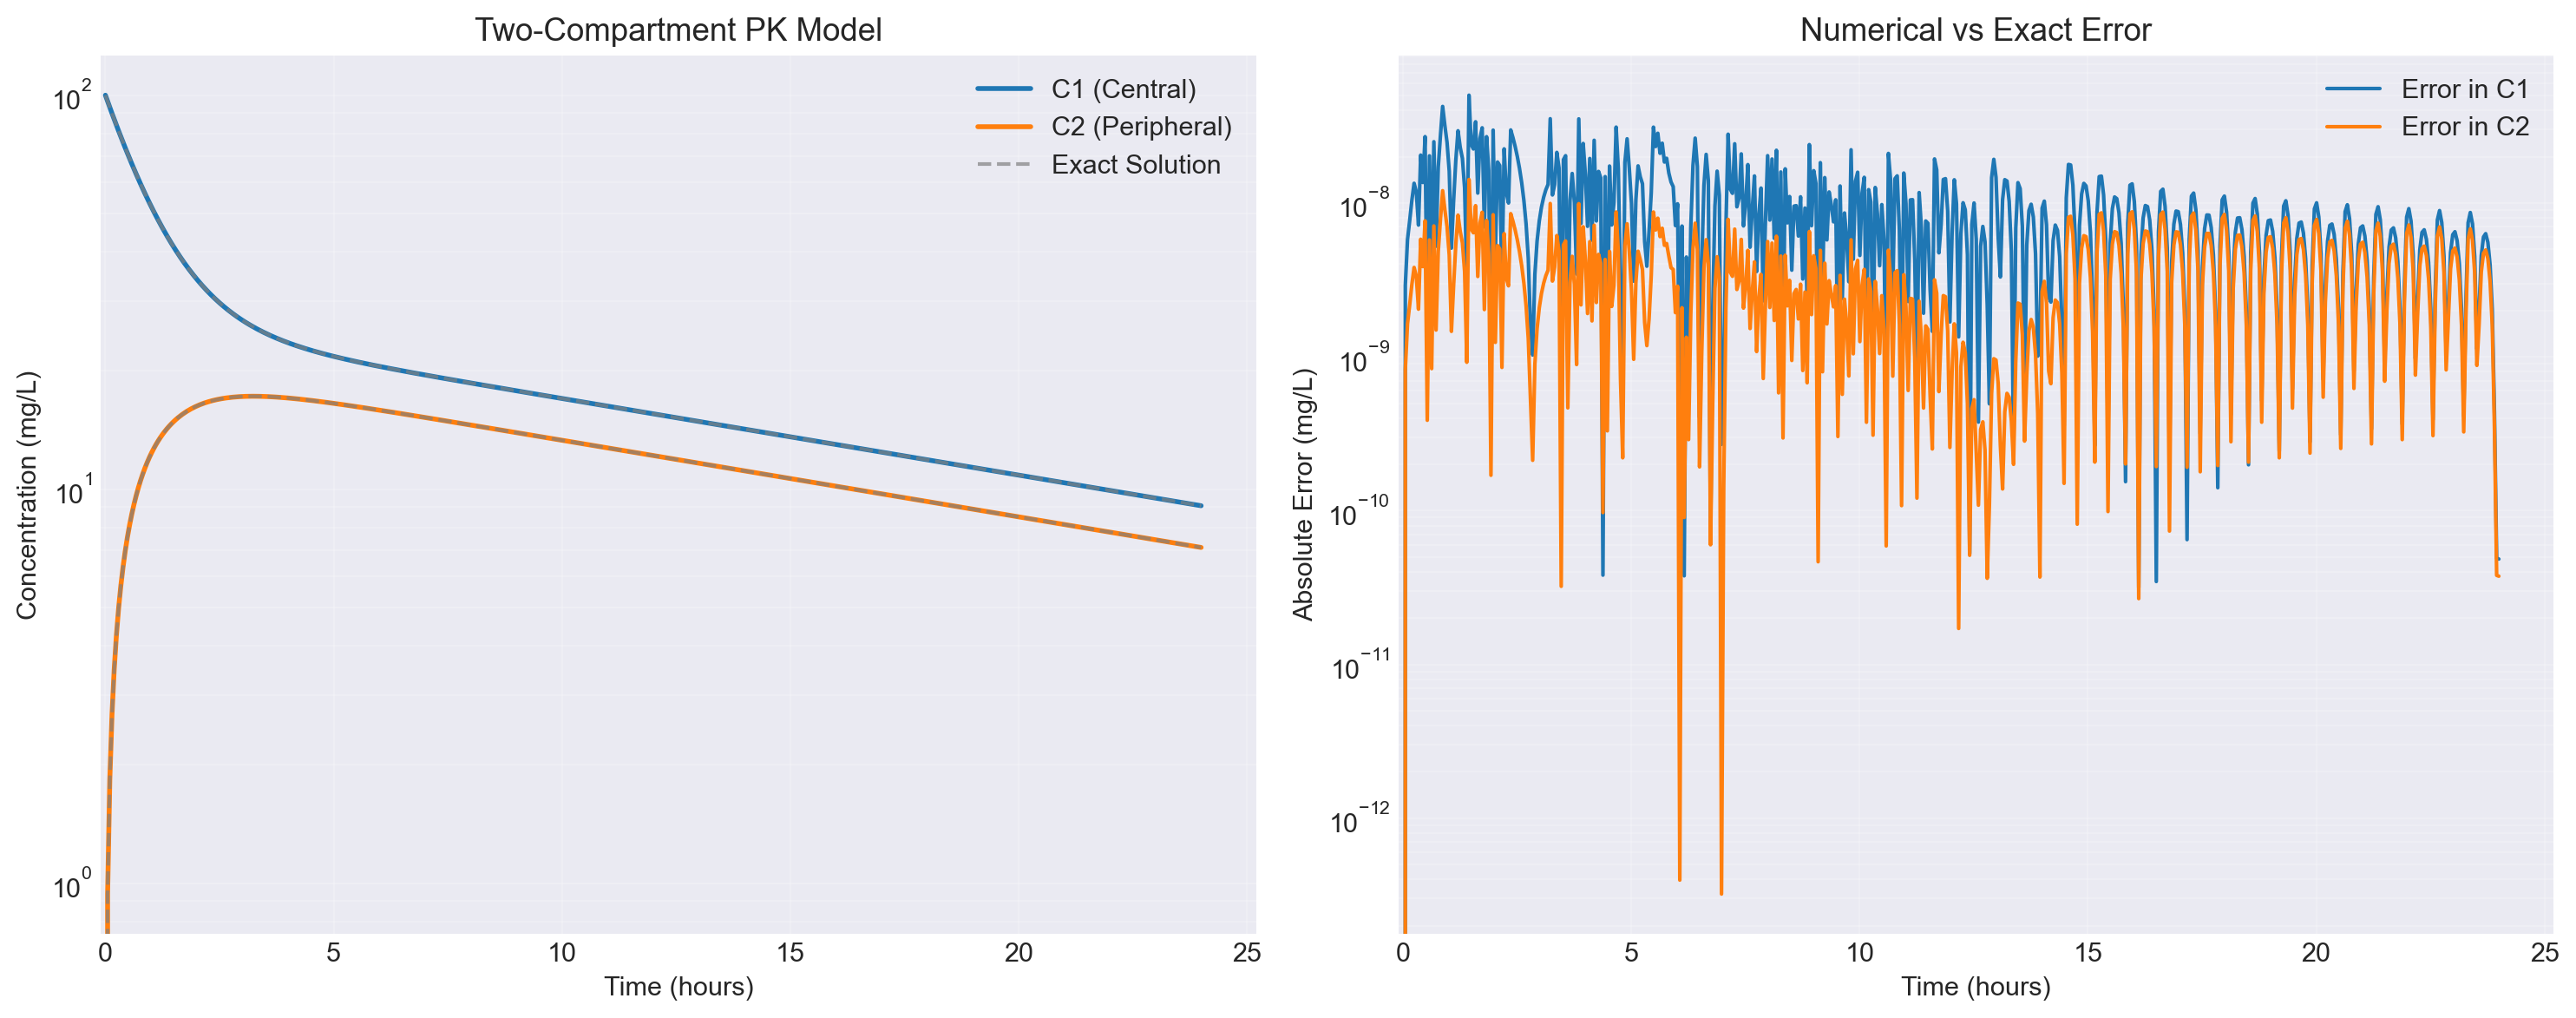

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.810e-02 ...  2.395e+01  2.400e+01]
        y: [[ 1.000e+02  9.648e+01 ...  9.095e+00  9.075e+00]
            [ 0.000e+00  9.380e-01 ...  7.127e+00  7.111e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1309
     njev: 3
      nlu: 52

In [311]:
# Reference parameters
pk_params = {'k12': 0.6, 'k21': 0.3, 'ke': 0.15, 'V1': 10.0, 'V2': 30.0}
dose = 1000.0  # mg

# Initial conditions
C1_0 = dose / pk_params['V1']
C2_0 = 0.0
y0_pk = [C1_0, C2_0]

# Time span
t_span = (0, 24) # 24 hours
t_eval = np.linspace(0, 24, 500)

# Solve the ODE using solve_ivp with method='Radau', rtol=1e-8, atol=1e-10
# Hint: use a lambda to pass params:  fun=lambda t, y: pk_rhs(t, y, pk_params)
# Store the solution object as `sol_pk`
fun = partial(pk_rhs, params=pk_params)
sol_pk = solve_ivp(
    fun,
    t_span,
    y0_pk,
    method="Radau",
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-10
)
C1_t, C2_t = sol_pk.y

# Let's get the exact solution
def exact_solution(t, C1_0, pk_params):
    k12, k21, ke = pk_params['k12'], pk_params['k21'], pk_params['ke']
    V1, V2 = pk_params['V1'], pk_params['V2']
    D = C1_0 * V1

    alpha = (k12 + k21 + ke + np.sqrt((k12 + k21 + ke)**2 - 4*k21*ke)) / 2
    beta = (k12 + k21 + ke - np.sqrt((k12 + k21 + ke)**2 - 4*k21*ke)) / 2

    A_coeff = (C1_0 * (alpha - k21 )) / (alpha - beta)
    B_coeff = (C1_0 * (k21 - beta)) / (alpha - beta)

    C1_t = A_coeff * np.exp(-alpha * t) + B_coeff * np.exp(-beta * t)
    C2_t = (D / V2) * (k12 / (alpha - beta)) * (np.exp(-beta * t) - np.exp(-alpha * t))
    return C1_t, C2_t

C1_exact, C2_exact = exact_solution(t_eval, C1_0, pk_params)

# Error
error_C1 = np.abs(C1_t - C1_exact)
error_C2 = np.abs(C2_t - C2_exact)

# Plot C1 and C2 vs time on the same axes
# Use plt.semilogy or ax.set_yscale('log')
# Label your axes and add a legend
# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Left Plot: Concentrations ---
ax1.semilogy(t_eval, C1_t, label='C1 (Central)', linewidth=2)
ax1.semilogy(t_eval, C2_t, label='C2 (Peripheral)', linewidth=2)
ax1.semilogy(t_eval, C1_exact, label='Exact Solution', linestyle='dashed', c="gray", alpha=0.7)
ax1.semilogy(t_eval, C2_exact, linestyle='dashed', c="gray", alpha=0.7)

ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Concentration (mg/L)')
ax1.set_title('Two-Compartment PK Model')
ax1.set_xlim(-0.1)
ax1.grid(True, which="both", ls="-", alpha=0.2)
ax1.legend()

# --- Right Plot: Absolute Error ---
ax2.semilogy(t_eval, error_C1, label='Error in C1', color='tab:blue')
ax2.semilogy(t_eval, error_C2, label='Error in C2', color='tab:orange')

ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('Absolute Error (mg/L)')
ax2.set_title('Numerical vs Exact Error')
ax2.set_xlim(-0.1)
ax2.grid(True, which="both", ls="-", alpha=0.2)
ax2.legend()

plt.tight_layout() # Ensures labels don't overlap
plt.show()

sol_pk

### Verification

- ✅ $C_1$ starts at 100 mg/L and drops rapidly (distribution phase), then more slowly (elimination phase).
- ✅ $C_2$ rises from 0, peaks around 1–3 hours, then declines.
- ✅ On the log-scale plot, $C_1$ shows a clear "two-slope" pattern.
- ✅ Error against true solution is equal or less than the `atol` value

---

## Section 2 — The Forward Model II: Coupling with Toxicity Response

### Recap

The toxicity model describes cell damage as a function of drug exposure in the tissue:

$$\frac{dD}{dt} = k_{\text{damage}} \cdot f(C_2(t)) \cdot (1 - D) - k_{\text{repair}} \cdot D$$

where $D \in [0, 1]$ is the damage variable and $f(C)$ is the **Hill function**:

$$f(C) = E_{\max} \cdot \frac{C^n}{EC_{50}^n + C^n}$$

Cell viability = $1 - D$.

> Note that this is a one-way system where D depends on C1 and C2 but C1 and C2 do **not** depend on D. A two-way coupled system could look like: 

> ``` dC1/dt = -(k12*(1 - D) + ke)*C1 + (V2/V1)*k21*C2 ```

> ```dC2/dt = (V1/V2)*k12*(1 - D)*C1 - k21*C2```

> ```dD/dt  = k_damage * f(C2) * (1 - D) - k_repair * D```

### Task 2.1 — Implement the Hill function

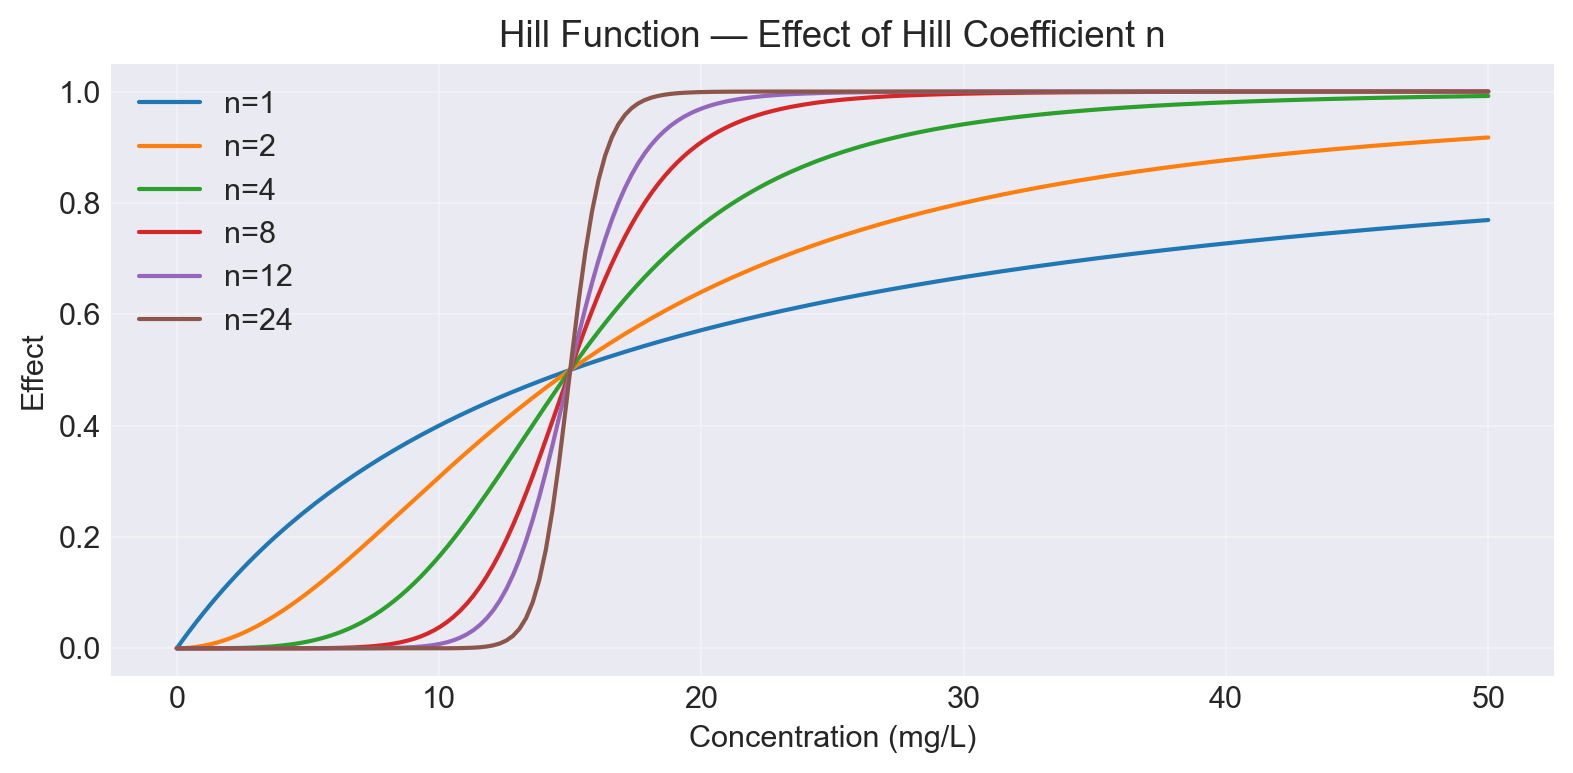

In [312]:
def hill(C, Emax, EC50, n):
    """
    Hill (sigmoid Emax) function.

    Parameters
    ----------
    C    : float or array — drug concentration
    Emax : float — maximum effect
    EC50 : float — concentration at half-maximal effect
    n    : float — Hill coefficient (steepness)

    Returns
    -------
    float or array — effect value in [0, Emax]
    """
    Cn = C**n
    EC50n = EC50 ** n
    return Emax * Cn / (EC50n + Cn)


# Quick visual check: plot the Hill function for different n values
C_range = np.linspace(0, 50, 200)
fig, ax = plt.subplots(figsize=(8, 4))
for n_val in [1, 2, 4, 8, 12, 24]:
    hill_n = hill(C_range, Emax=1.0, EC50=15.0, n=n_val)
    ax.plot(C_range, hill_n, label=f"n={n_val}")
ax.set_xlabel('Concentration (mg/L)')
ax.set_ylabel('Effect')
ax.set_title('Hill Function — Effect of Hill Coefficient n')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- ✅ All functions have a tipping point around `EC50`
- ✅ Higher `n` results in sharp effect changes around `EC50` - implies effect of the drug is more unstable and needs careful dosage
- ✅ Lower `n` results in smooth effect changes overall - implies effect of the drug is steady and less sensitive to doses


### Task 2.2 — Implement the coupled PK-toxicity system (monolithic)

Write a function `coupled_rhs(t, y, params)` for the full 3-variable system $[C_1, C_2, D]$.

The `params` dict will contain all PK parameters plus: `'k_damage'`, `'k_repair'`, `'Emax'`, `'EC50'`, `'n'`.

In [313]:
def coupled_rhs(t, y, params):
    """
    Right-hand side of the coupled PK + toxicity ODE system.

    Parameters
    ----------
    t : float
    y : array-like, shape (3,) — [C1, C2, D]
    params : dict with PK keys + 'k_damage', 'k_repair', 'Emax', 'EC50', 'n'

    Returns
    -------
    list of float — [dC1_dt, dC2_dt, dD_dt]
    """
    C1, C2, D = y

    # 1. Compute dC1_dt and dC2_dt (reuse your PK equations)
    dC1dt, dC2dt = pk_rhs(t, [C1, C2], params)

    # 2. Compute the Hill function value using C2
    Emax = params["Emax"]
    EC50 = params["EC50"]
    n = params["n"]
    EC2 = hill(C2, Emax, EC50, n) # returns float because C2 is float

    # 3. Compute dD_dt from the damage-recovery ODE
    kd = params["k_damage"]
    kr = params["k_repair"]
    dDdt = kd * EC2 * (1 - D) - kr * D # damage occurs only on living cells
                                       # repair is modelled linearly to damage
    
    # 4. Return [dC1_dt, dC2_dt, dD_dt]
    return dC1dt, dC2dt, dDdt

### Task 2.3 — Solve the coupled system and plot all three variables

Use the full parameter set below. Plot $C_1$, $C_2$, and the **cell viability** $V = 1 - D$ on separate subplots.

**Additional toxicity parameters:**
| Parameter | Value |
|-----------|-------|
| $k_{\text{damage}}$ | 2.0 |
| $k_{\text{repair}}$ | 0.1 |
| $E_{\max}$ | 1.0 |
| $EC_{50}$ | 15.0 |
| $n$ | 2 |

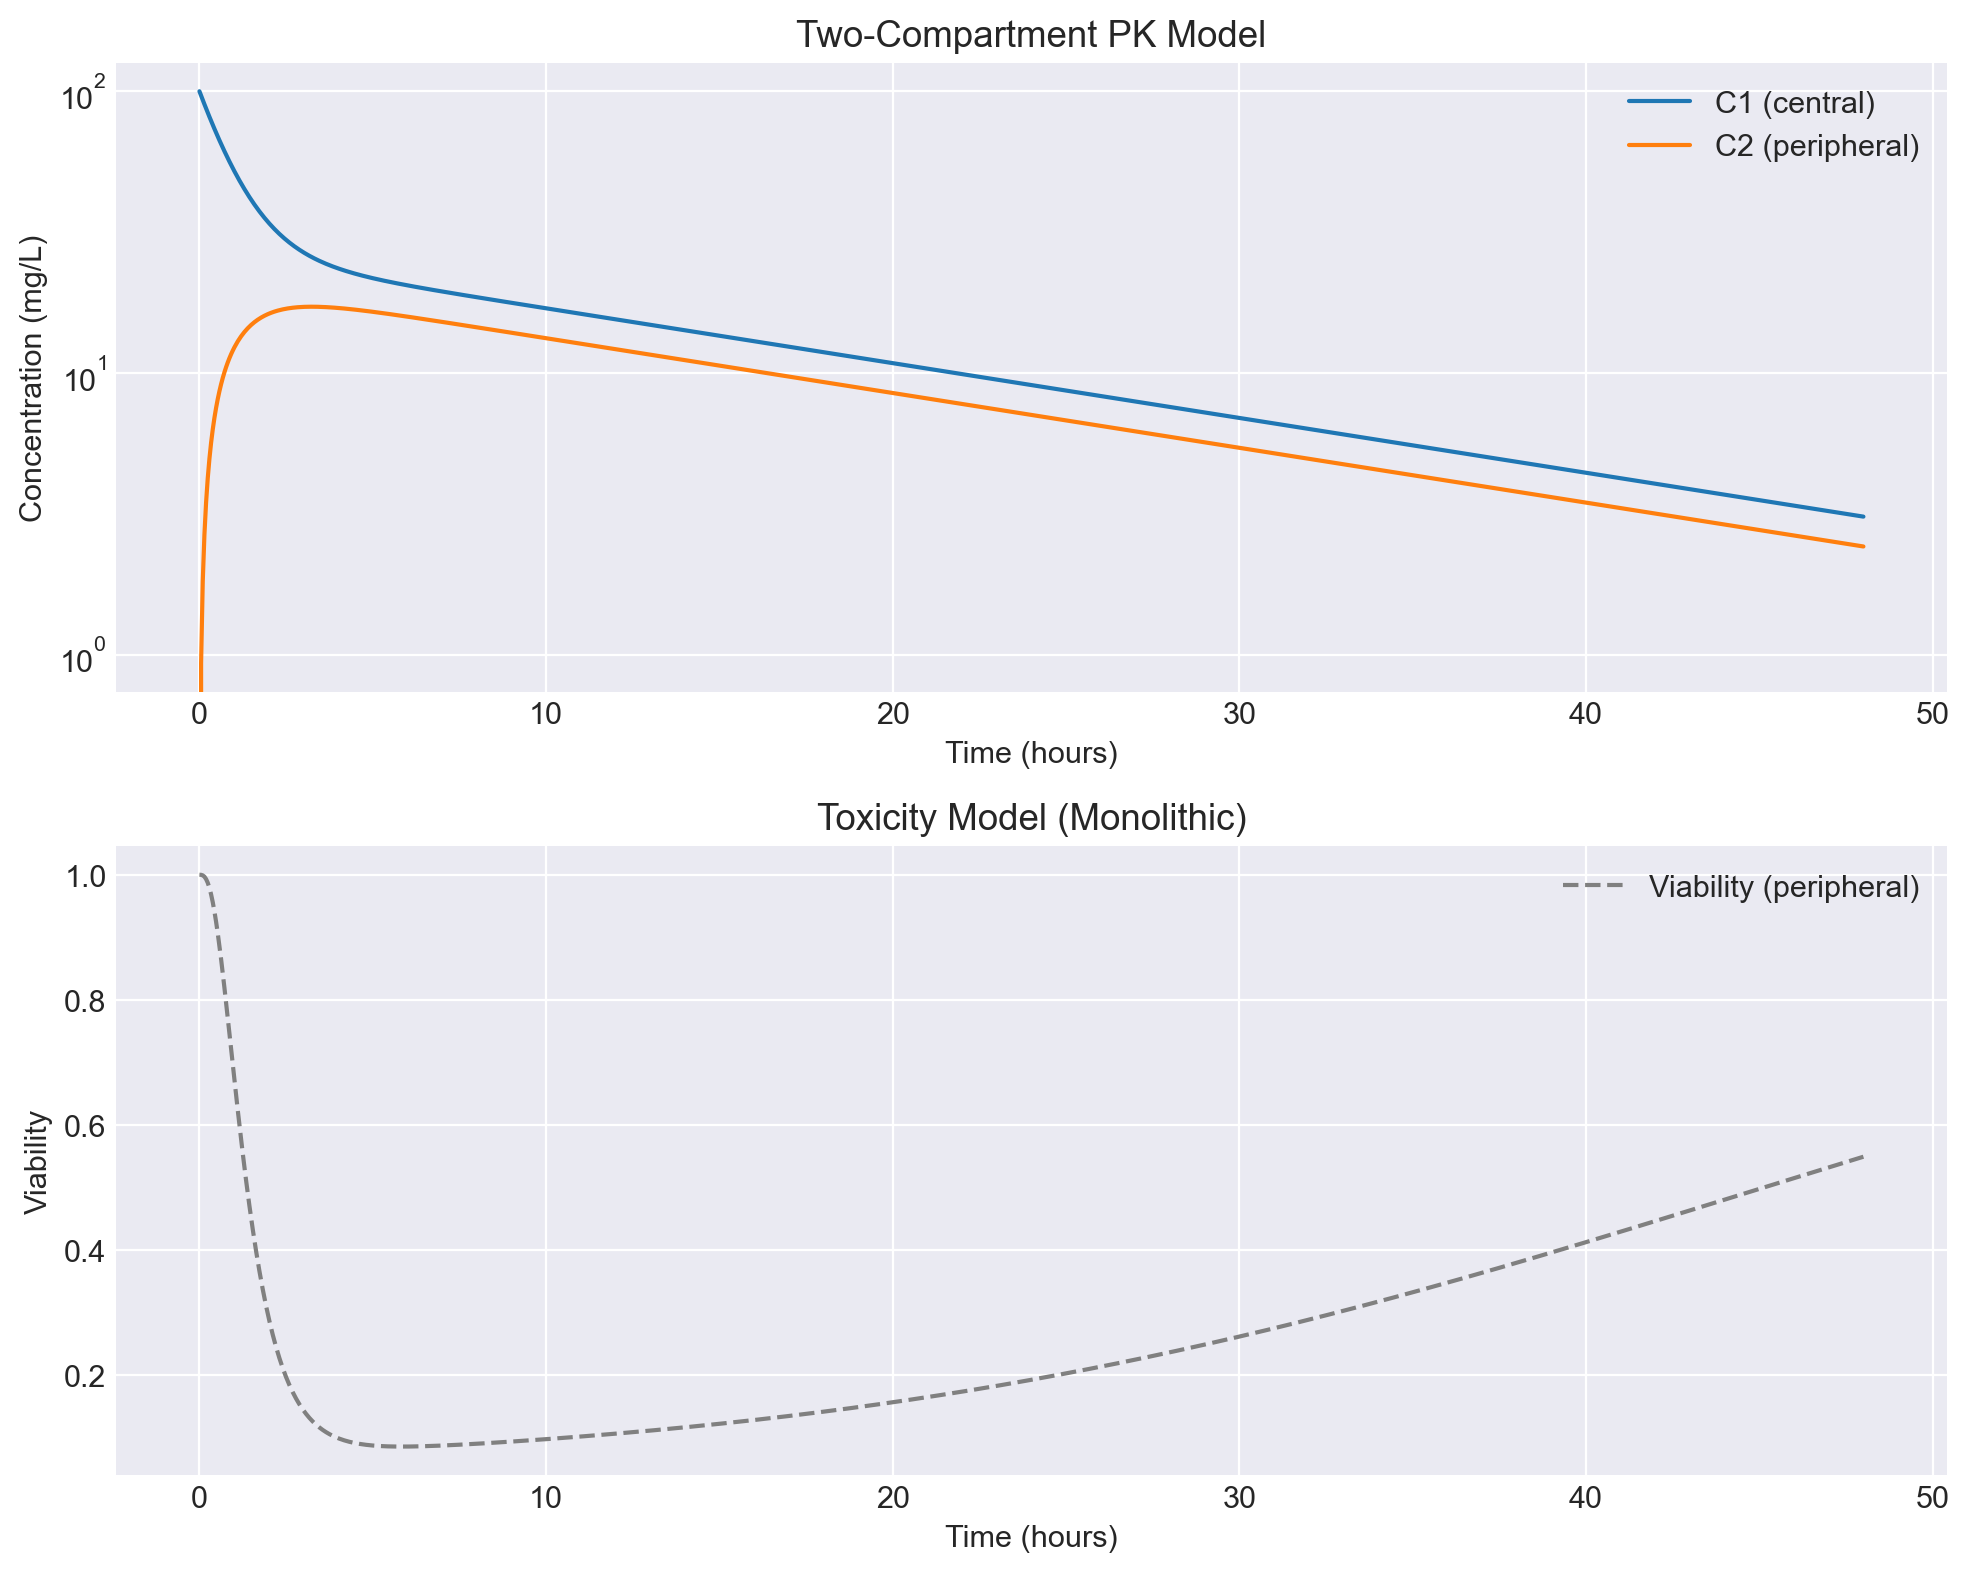

In [314]:
# Full parameter set
full_params = {
    'k12': 0.6, 'k21': 0.3, 'ke': 0.15,
    'V1': 10.0, 'V2': 30.0,
    'k_damage': 2.0, 'k_repair': 0.1,
    'Emax': 1.0, 'EC50': 15.0, 'n': 2.0
}

# Initial conditions: [C1_0, C2_0, D_0]
y0_coupled = [dose / full_params['V1'], 0.0, 0.0]
t_span_long = (0, 48)
t_eval_long = np.linspace(0, 48, 1000)

# Solve the coupled system using solve_ivp (Radau, tight tolerances)
# Store as sol_coupled
fun = partial(coupled_rhs, params=full_params)
sol_coupled = solve_ivp(
    fun,
    t_span_long,
    y0_coupled,
    method="Radau",
    t_eval=t_eval_long,
    rtol=1e-8,
    atol=1e-10
)
C1_t, C2_t, Dt = sol_coupled.y
Vt = 1 - Dt

# Create a figure with 3 subplots (vertically stacked)
# Subplot 1: C1(t) — Central concentration
# Subplot 2: C2(t) — Tissue concentration
# Subplot 3: Viability = 1 - D(t)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# --- Concentration Plots ---
ax1.semilogy(t_eval_long, C1_t, label="C1 (central)")
ax1.semilogy(t_eval_long, C2_t, label="C2 (peripheral)")
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Concentration (mg/L)')
ax1.set_title('Two-Compartment PK Model')
ax1.legend()


# --- Vitality  Plot ---
ax2.plot(t_eval_long, Vt, label="Viability (peripheral)", linestyle='dashed', c="gray")
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('Viability')
ax2.set_title('Toxicity Model (Monolithic)')
ax2.legend()

plt.tight_layout()
plt.show()



- ✅ Maximum damage occuring at ~3-4h after dose injection, at peak C2, after which the repairing mechanism starts to take a larger effect


### Task 2.4 — Sequential coupling: solve PK first, then toxicity

Implement the **loosely coupled** approach:
1. Solve the PK system alone to get $C_2(t)$.
2. Build an interpolation function for $C_2(t)$.
3. Solve the toxicity ODE using the interpolated $C_2(t)$ as a forcing function.
4. Compare the viability curves from the monolithic and sequential approaches on the same plot.

MIN: 0.00E+00,    MAX: 2.44E-08,    MEAN:6.70E-10,    STD:1.62E-09


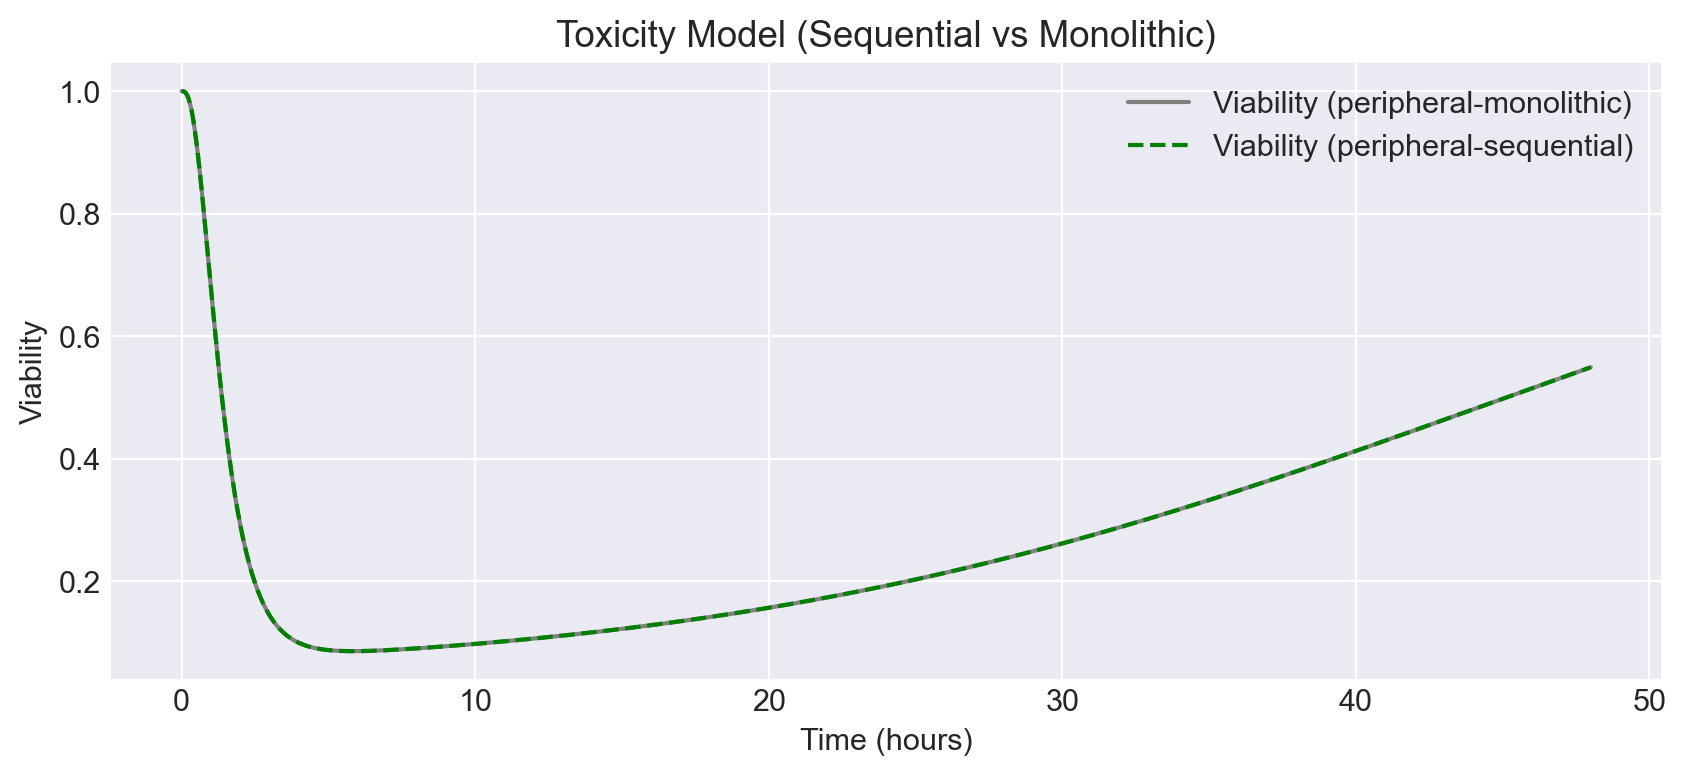

In [315]:
def tox_rhs_sequential(t, y, C2_func, params):
    """
    Toxicity ODE when C2(t) is provided as an interpolation function.

    Parameters
    ----------
    t : float
    y : array-like, shape (1,) — [D]
    C2_func : callable — interpolated C2(t)
    params : dict with 'k_damage', 'k_repair', 'Emax', 'EC50', 'n'

    Returns
    -------
    list of float — [dD_dt]
    """
    D = y[0]
    C2 = C2_func(t)

    # Compute the Hill function value using C2
    Emax = params["Emax"]
    EC50 = params["EC50"]
    n = params["n"]
    EC2 = hill(C2, Emax, EC50, n)

    # Compute dD_dt from the damage-recovery ODE
    kd = params["k_damage"]
    kr = params["k_repair"]
    dDdt = kd * EC2 * (1 - D) - kr * D

    return [dDdt]

# Step 1: Solve PK model alone over [0, 48] hours
y0_pk_sequential = [dose / full_params['V1'], 0.0] # C1_0 and C2_0
sol_pk_sequential = solve_ivp(
    partial(pk_rhs, params=full_params),
    t_span_long,
    y0 = y0_pk_sequential,
    method="Radau",
    t_eval=t_eval_long,
    rtol=1e-8,
    atol=1e-10
)
# Step 2: Create an interpolation function for C2(t) using interp1d
_, C2_t = sol_pk_sequential.y
C2_interp = interp1d(t_eval_long, C2_t, kind="quadratic")

# Sanity check for interpolation
t1, t2 = t_eval_long[10], t_eval_long[11]
assert C2_t[10] < C2_interp((t1+t2)/2.) < C2_t[11]

# Step 3: Solve the toxicity ODE with D(0) = 0
y0_tox_sequential = [0] # D only
sol_tox_sequential = solve_ivp(
    partial(tox_rhs_sequential, C2_func=C2_interp, params=full_params),
    t_span_long,
    y0 = y0_tox_sequential,
    method="Radau",
    t_eval=t_eval_long,
    rtol=1e-8,
    atol=1e-10
)
Dt_seq = sol_tox_sequential.y[0]
Vt_seq = 1 - Dt_seq

# Step 4: Plot both viability curves (monolithic vs sequential) on same axes

fig, ax = plt.subplots(1, 1)
ax.plot(t_eval_long, Vt, label="Viability (peripheral-monolithic)", linestyle='solid', c="gray")
ax.plot(t_eval_long, Vt_seq, label="Viability (peripheral-sequential)", linestyle='dashed', c="green")
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Viability')
ax.set_title('Toxicity Model (Sequential vs Monolithic)')
ax.legend()

V_error = np.abs(Vt_seq - Vt)
print("MIN: {:.2E},    MAX: {:.2E},    MEAN:{:.2E},    STD:{:.2E}".format(V_error.min(), V_error.max(), V_error.mean(), V_error.std()))
assert V_error.max() <= 2e-4


###  Verification

- ✅ For one-way coupling, the two approaches produce nearly identical viability curves.
- ✅ Differences will arise from interpolation density and solver tolerances.

---

## Section 3 — The Inverse Problem: Parameter Estimation with Local Methods

### Overview

Now we reverse the problem. Given *observed data*, recover the parameters.

We will:
1. Generate synthetic "experimental" data by running the model with known parameters and adding noise.
2. Define an objective function (sum of squared residuals).
3. Fit parameters using L-BFGS-B and `least_squares`.
4. Observe sensitivity to initial guess (local minima).

### Task 3.1 — Generate synthetic data

Run the coupled model with the reference parameters and add Gaussian noise to create synthetic observations at 15 time points.

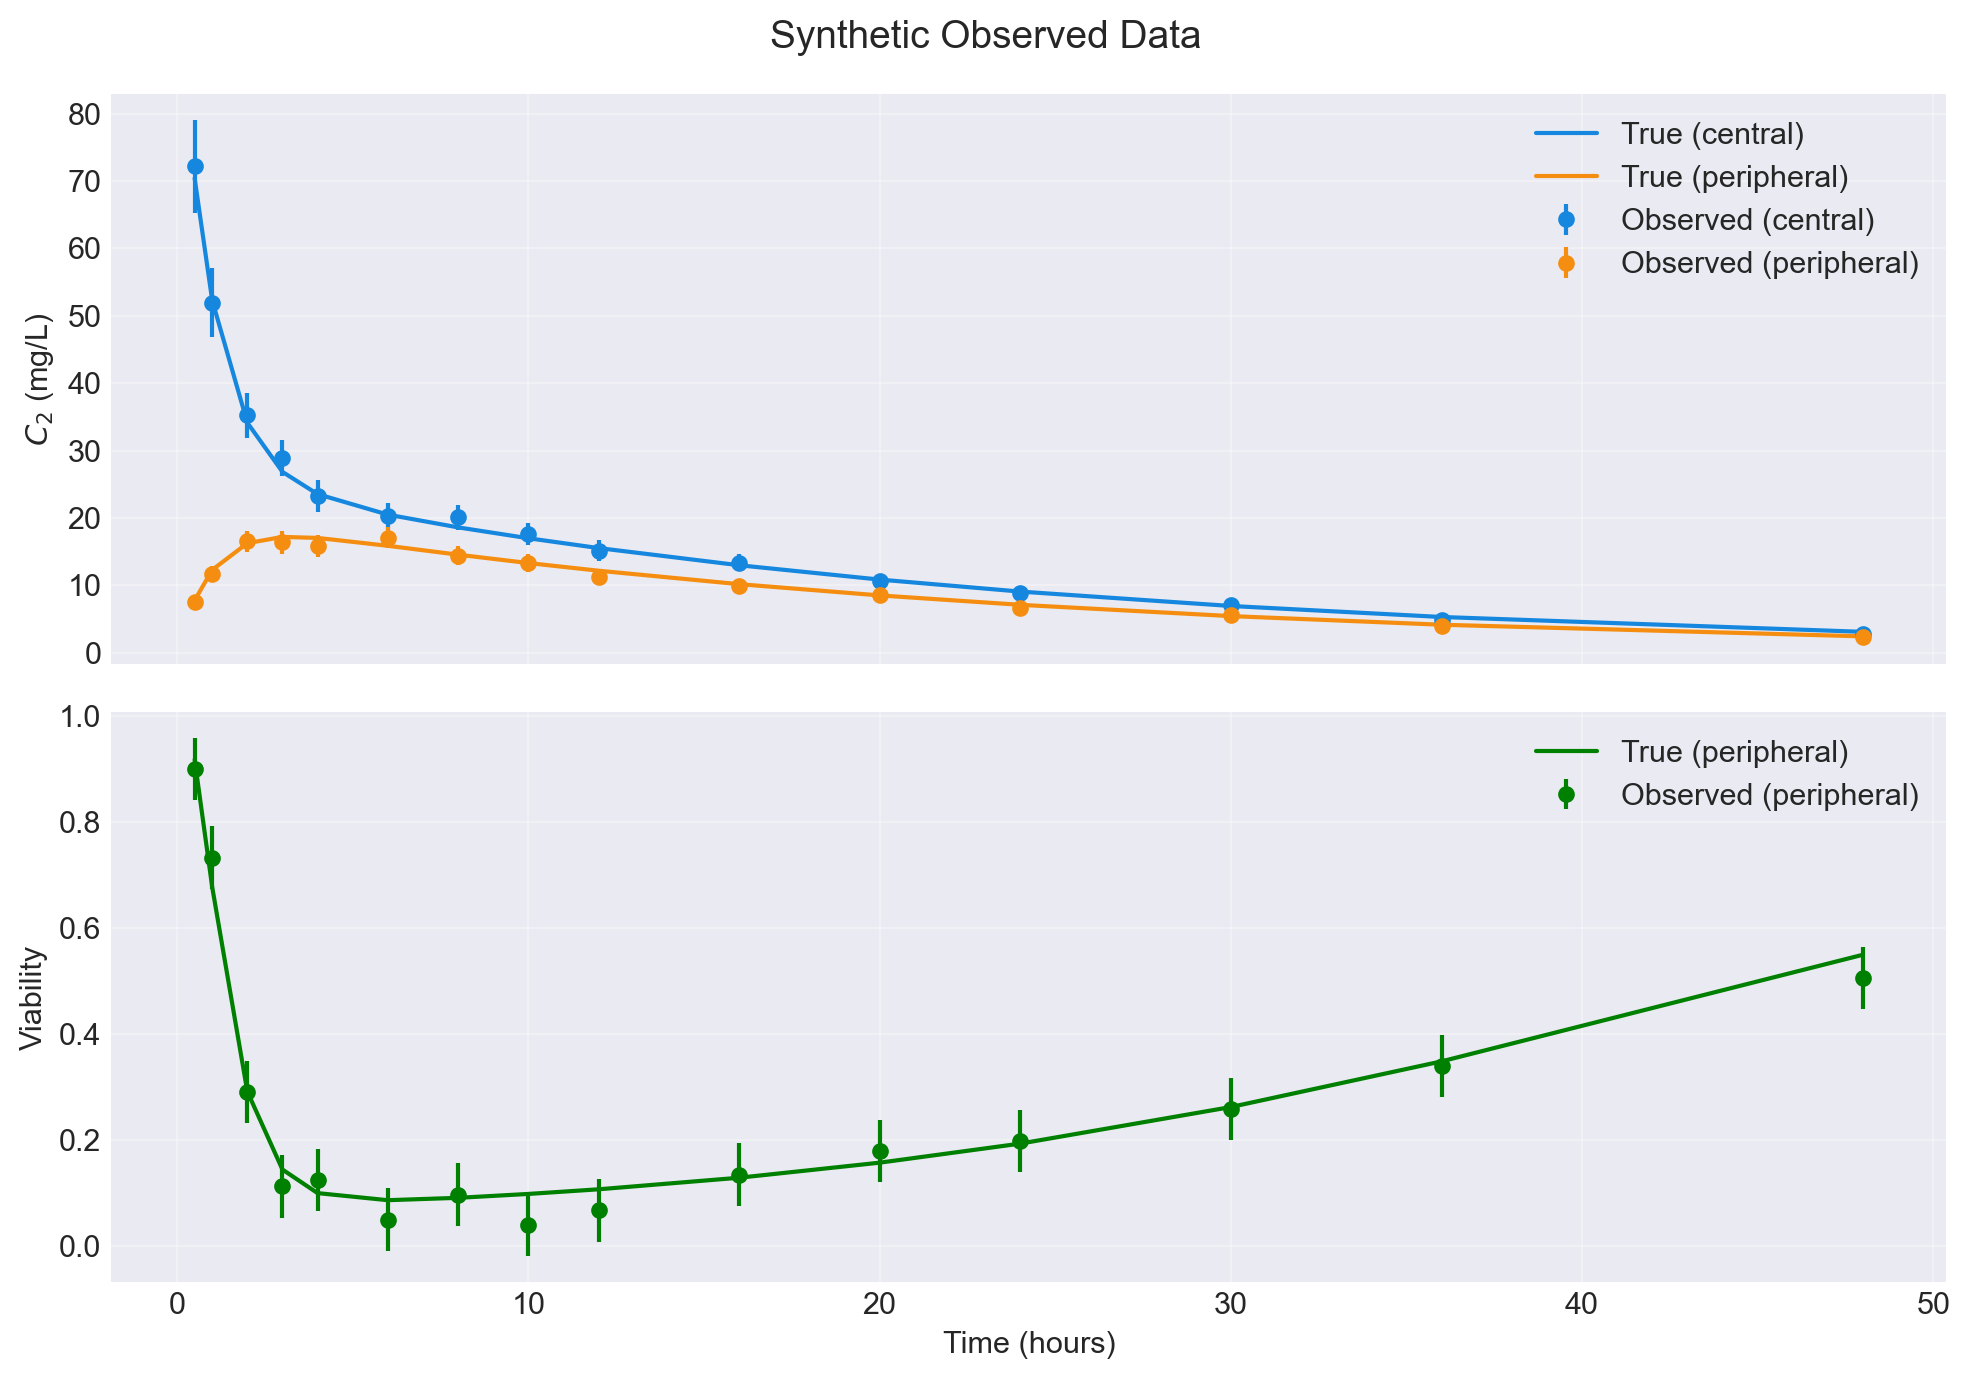

In [316]:
# Generate synthetic data from the coupled model
np.random.seed(42)

t_obs = np.array([0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 30, 36, 48])

# Solve the coupled model at observation times
sol_true = solve_ivp(
    fun=lambda t, y: coupled_rhs(t, y, full_params),
    t_span=(0, 48), y0=y0_coupled, t_eval=t_obs,
    method='Radau', rtol=1e-10, atol=1e-12
)

C1_true = sol_true.y[0]
C2_true = sol_true.y[1]
viability_true = 1 - sol_true.y[2]

# Add noise
sigma_C1 = 0.05 * C1_true   # 5% relative noise
sigma_C2 = 0.05 * C2_true   # 5% relative noise
sigma_V  = 0.03 * np.ones_like(viability_true)  # 3% absolute noise


# Generate noisy observations:
C1_obs = C1_true + sigma_C1 * np.random.randn(len(t_obs))
C2_obs = C2_true + sigma_C2 * np.random.randn(len(t_obs))
V_obs = np.clip(viability_true + sigma_V * np.random.randn(len(t_obs)), 0., 1.)

# Plot the noisy data points (scatter) on top of the true model curves (lines)
# Use 3 subplots: C1, C2, Viability
# We can also plot error bars knowing that the max 95% confidence interval is given by 1.96 sqrt(var)
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t_obs, C1_true, '-', c="#1687DE", linewidth=1.5, label='True (central)')
axes[0].errorbar(t_obs, C1_obs, yerr=1.96*sigma_C1, fmt='o', c="#1687DE", markersize=5, label='Observed (central)')
axes[0].set_ylabel('$C_1$ (mg/L)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[0].plot(t_obs, C2_true, '-', c="#F58E10", linewidth=1.5, label='True (peripheral)')
axes[0].errorbar(t_obs, C2_obs, yerr=1.96*sigma_C2, fmt='o', c="#F58E10", markersize=5, label='Observed (peripheral)')
axes[0].set_ylabel('$C_2$ (mg/L)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_obs, viability_true, '-', c="green", linewidth=1.5, label='True (peripheral)')
axes[1].errorbar(t_obs, V_obs, yerr=1.96*sigma_V, fmt='o', c="green", markersize=5, label='Observed (peripheral)')
axes[1].set_ylabel('Viability')
axes[1].set_xlabel('Time (hours)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Synthetic Observed Data', fontsize=14)
plt.tight_layout()
plt.show()

### Task 3.2 — Define the objective function

Write a function that takes a parameter vector $\theta$ (in **log-space**), runs the forward model, and returns the **weighted residual vector** (for use with `least_squares`) or the scalar sum of squares (for use with `minimize`).

**Parameter ordering:** `[log(k12), log(k21), log(ke), log(k_damage), log(k_repair), log(EC50), log(n)]`

We fix $V_1=10$, $V_2=30$, and $E_{\max}=1$ to reduce the dimensionality (these are typically known from prior experiments).

> **Why log-space?** Rate constants span orders of magnitude. Optimising in log-space makes the landscape smoother and prevents the optimiser from trying negative values.

In [317]:
# Fixed parameters
V1_fixed = 10.0
V2_fixed = 30.0
Emax_fixed = 1.0

# Parameter names (in log-space)
param_names = ['log(k12)', 'log(k21)', 'log(ke)', 'log(k_damage)', 'log(k_repair)', 'log(EC50)', 'log(n)']

# True values in log-space (for reference)
theta_true = np.log([0.6, 0.3, 0.15, 2.0, 0.1, 15.0, 2.0])

def residuals(log_theta):
    """
    Compute the weighted residual vector.

    Parameters
    ----------
    log_theta : array, shape (7,) — parameters in log-space

    Returns
    -------
    array — concatenated weighted residuals [r_C1, r_C2, r_V]
    """
    # Convert log_theta back to natural space: theta = np.exp(log_theta)
    theta = np.exp(log_theta)
    k12, k21, ke, k_damage, k_repair, EC50, n = theta
    
    # Build the params dict
    params = {
        'k12': k12, 'k21': k21, 'ke': ke,
        'V1': V1_fixed, 'V2': V2_fixed,
        'k_damage': k_damage, 'k_repair': k_repair,
        'Emax': Emax_fixed, 'EC50': EC50, 'n': n
    }

    try:
        # Solve the coupled ODE at t_obs
        sol = solve_ivp(
                fun=lambda t, y: coupled_rhs(t, y, params),
                t_span=(0, 48), y0=[dose / V1_fixed, 0.0, 0.0],
                t_eval=t_obs, method='Radau', rtol=1e-8, atol=1e-10
            )

        # If the solver fails, return a large residual vector (e.g., 1e6 * np.ones(3*len(t_obs)))
        # This would happen when the ODE is unstable for the given parameters, which can occur during optimization
        if not sol.success or sol.y.shape[1] != len(t_obs):
            return 1e6 * np.ones(3 * len(t_obs))

        # Extract the ODE solution
        C1_model = sol.y[0]
        C2_model = sol.y[1]
        V_model  = 1 - sol.y[2]
        
        # Compute weighted residuals (assuming we know the noise):
        r_C1 = (C1_obs - C1_model) / sigma_C1
        r_C2 = (C2_obs - C2_model) / sigma_C2
        r_V  = (V_obs  - V_model)  / sigma_V

        # Return np.concatenate([r_C1, r_C2, r_V])
        return np.concatenate([r_C1, r_C2, r_V])
    
    except Exception:
        # This is a catch-all for any unexpected errors during ODE solving or residual computation
        # This is necessary because during optimization, the algorithm may propose parameters that lead to numerical issues (e.g., negative rates, extremely stiff ODEs, etc.)
        # We solve it by penalising the objective with a large residual value
        return 1e6 * np.ones(3 * len(t_obs))
    

def objective(log_theta):
    """Scalar objective = sum of squared residuals."""
    r = residuals(log_theta)
    return np.sum(r**2)

### Task 3.3 — Fit with L-BFGS-B from a *good* initial guess

Start from a point close to the truth (within a factor of 2) and observe convergence.

In [318]:
# "Good" initial guess: true values perturbed by a factor of ~1.5
np.random.seed(7)
theta_init_good = theta_true + 0.4 * np.random.randn(7)

# Bounds in log-space (very wide)
bounds_log = [(-3, 3)] * 7  # exp(-3) ≈ 0.05, exp(3) ≈ 20

# Run scipy.optimize.minimize with method='L-BFGS-B'
# Store the result as `res_good`
res_good = minimize(
    fun=objective,
    x0=theta_init_good,
    method="L-BFGS-B",
    bounds=bounds_log,
    options={'maxiter': 500, 'ftol': 1e-12}  # set a max number of iterations and a tight function tolerance for convergence
)
print(res_good)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 29.289691757053365
        x: [-5.574e-01 -1.227e+00 -1.891e+00  1.017e+00 -2.478e+00
             3.000e+00  6.404e-01]
      nit: 47
      jac: [ 1.030e-05  4.512e-05  1.489e-04 -1.208e-05  5.400e-05
            -3.777e+00  8.562e-05]
     nfev: 504
     njev: 63
 hess_inv: <7x7 LbfgsInvHessProduct with dtype=float64>


In [319]:
# Print a comparison table: parameter name | true value | estimated value | ratio
# Use np.exp() to convert back to natural space
import pandas as pd
df = pd.DataFrame({
    'Parameter': [n[4:-1] for n in param_names],  # remove 'log()' from parameter names for clarity
    'True Value': np.exp(theta_true),
    'Estimated Value': np.exp(res_good.x),
    'Ratio (Est/True)': np.exp(res_good.x) / np.exp(theta_true)
})
print(df.to_string(index=False))

Parameter  True Value  Estimated Value  Ratio (Est/True)
      k12        0.60         0.572723          0.954539
      k21        0.30         0.293311          0.977704
       ke        0.15         0.150950          1.006333
 k_damage        2.00         2.765768          1.382884
 k_repair        0.10         0.083944          0.839436
     EC50       15.00        20.085537          1.339036
        n        2.00         1.897313          0.948656


### Task 3.4 — Fit from a *bad* initial guess and observe the local minimum trap

Now start far from the truth. Compare the result to the good-start fit.

In [320]:
# "Bad" initial guess: far from truth
theta_init_bad = np.log([0.05, 2.0, 4.0, 0.01, 9.0, 0.2, 0.01])

# Run L-BFGS-B from the bad initial guess
# Store as res_bad
res_bad = minimize(
    fun=objective,
    x0=theta_init_bad,
    method="L-BFGS-B",
    bounds=bounds_log,
    options={'maxiter': 500, 'ftol': 1e-12}  # set a max number of iterations and a tight function tolerance for convergence
)
res_bad

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 45000000000000.0
        x: [-2.996e+00  6.931e-01  1.386e+00 -3.000e+00  2.197e+00
            -1.609e+00 -3.000e+00]
      nit: 0
      jac: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
             0.000e+00  0.000e+00]
     nfev: 8
     njev: 1
 hess_inv: <7x7 LbfgsInvHessProduct with dtype=float64>

In [321]:
# Print the same comparison table
# Compare res_bad.fun vs res_good.fun — is the bad start stuck in a local minimum?
df_bad = pd.DataFrame({
    'Estimated Value (bad init)': np.exp(res_bad.x),
    'Ratio (bad init) (Est/True)': np.exp(res_bad.x) / np.exp(theta_true),
})
df_bad = pd.concat((df, df_bad), axis=1)
print(df_bad.to_string(index=False))

print(f"\nGood-start objective: {res_good.fun:.2f}")
print(f"Bad-start objective:  {res_bad.fun:.2f}")
if res_bad.fun > 1.5 * res_good.fun:
    print("→ The bad start found a LOCAL minimum (higher objective).")
else:
    print("→ Both starts found similar minima.")

Parameter  True Value  Estimated Value  Ratio (Est/True)  Estimated Value (bad init)  Ratio (bad init) (Est/True)
      k12        0.60         0.572723          0.954539                    0.050000                     0.083333
      k21        0.30         0.293311          0.977704                    2.000000                     6.666667
       ke        0.15         0.150950          1.006333                    4.000000                    26.666667
 k_damage        2.00         2.765768          1.382884                    0.049787                     0.024894
 k_repair        0.10         0.083944          0.839436                    9.000000                    90.000000
     EC50       15.00        20.085537          1.339036                    0.200000                     0.013333
        n        2.00         1.897313          0.948656                    0.049787                     0.024894

Good-start objective: 29.29
Bad-start objective:  45000000000000.00
→ The bad start fou

### Task 3.5 — Use `least_squares` (Levenberg-Marquardt)

Refit using `scipy.optimize.least_squares`, which exploits the sum-of-squares structure. Compare convergence speed (number of function evaluations) to L-BFGS-B.

In [322]:
# YOUR CODE HERE
# Use scipy.optimize.least_squares with the residuals function
# Start from theta_init_good
# Set bounds=(lower_bounds, upper_bounds) — convert bounds_log format
# Store as res_ls
lb = np.array([b[0] for b in bounds_log])
ub = np.array([b[1] for b in bounds_log])

res_ls = least_squares(
    residuals,
    theta_init_good,
    bounds = (lb, ub),
    ftol = 1e-12,
    xtol=1e-12, gtol=1e-12    
)

res_ls

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 2.655e-01 -5.247e-01 ...  2.033e-01 -6.582e-01]
           x: [-5.574e-01 -1.227e+00 -1.891e+00  1.017e+00 -2.478e+00
                3.000e+00  6.404e-01]
        cost: 14.644845878525205
         jac: [[ 5.299e+00 -4.273e-01 ... -9.065e-08  0.000e+00]
               [ 9.438e+00 -1.668e+00 ...  1.217e-07  3.651e-07]
               ...
               [ 1.343e+01 -1.443e+01 ... -1.089e+01 -1.578e+01]
               [ 1.786e+01 -1.954e+01 ... -1.190e+01 -2.239e+01]]
        grad: [ 3.886e-06 -2.100e-06  7.240e-07  2.065e-08  2.880e-06
               -1.888e+00 -5.068e-07]
  optimality: 9.493278371999624e-06
 active_mask: [0 0 0 0 0 1 0]
        nfev: 16
        njev: 15

In [323]:
# Print parameter comparison table
df_ls = pd.DataFrame({
    'Estimated Value (ls good init)': np.exp(res_ls.x),
    'Ratio (ls good init) (Est/True)': np.exp(res_ls.x) / np.exp(theta_true),
})
df_ls = pd.concat((df_bad, df_ls), axis=1)
print(df_ls.to_string(index=False))

print("\nLBFGS-B good start functional: ", res_good.fun)
print("Least-Squares good start functional: ", res_ls.fun.mean())

print(f"\nNumber of LBFGS-B Function evaluations: {res_good.nfev}")
print(f"Number of Least Squares Function evaluations: {res_ls.nfev}")

# Print nfev for least_squares vs L-BFGS-B

Parameter  True Value  Estimated Value  Ratio (Est/True)  Estimated Value (bad init)  Ratio (bad init) (Est/True)  Estimated Value (ls good init)  Ratio (ls good init) (Est/True)
      k12        0.60         0.572723          0.954539                    0.050000                     0.083333                        0.572723                         0.954539
      k21        0.30         0.293311          0.977704                    2.000000                     6.666667                        0.293311                         0.977704
       ke        0.15         0.150950          1.006333                    4.000000                    26.666667                        0.150950                         1.006333
 k_damage        2.00         2.765768          1.382884                    0.049787                     0.024894                        2.765768                         1.382884
 k_repair        0.10         0.083944          0.839436                    9.000000                    9

###  Verification
- ✅ `least_squares` converges in fewer evaluations than L-BFGS-B for this L2 minimisation problem
- ✅ The bad-start L-BFGS-B convergest to a higher objective value, demonstrating the local minimum trap.

---

## Section 4 — The Inverse Problem: Parameter Estimation with Global Methods

### Task 4.1 — Differential Evolution

Use `scipy.optimize.differential_evolution` to search the full parameter space without requiring a good initial guess.

In [325]:
# Run differential_evolution with:
#   - bounds = bounds_log
#   - seed = 42
#   - tol = 1e-8
#   - maxiter = 300
#   - polish = True (runs a local optimiser on the best result)
# Store as res_de
# This may take 1-3 minutes.

res_de = differential_evolution(
    func=objective,
    bounds=bounds_log,
    seed=42,
    tol=1e-8,
    maxiter=10,
    polish=True, # runs L-BFGS-B at the end by default
)

res_de

             message: Maximum number of iterations has been exceeded.
             success: False
                 fun: 29.289691757880274
                   x: [-5.574e-01 -1.227e+00 -1.891e+00  1.017e+00
                       -2.478e+00  3.000e+00  6.404e-01]
                 nit: 10
                nfev: 1475
          population: [[-6.765e-01 -1.416e+00 ...  1.724e+00  9.600e-01]
                       [-1.404e+00 -1.424e+00 ...  1.452e+00  2.423e-01]
                       ...
                       [-3.716e-01 -9.329e-01 ... -1.196e+00  4.804e-01]
                       [-1.500e+00 -1.943e+00 ... -5.221e-01  8.988e-01]]
 population_energies: [ 2.929e+01  3.015e+03 ...  2.558e+03  2.270e+03]
                 jac: [ 7.564e-04 -5.464e-04  8.491e-05  1.106e-03
                       -8.370e-04 -3.779e+00 -1.778e-03]

In [326]:
# Print parameter comparison and objective value
df_de = pd.DataFrame({
    'Estimated Value (dif. evolution)': np.exp(res_de.x),
    'Ratio (dif. evolution) (Est/True)': np.exp(res_de.x) / np.exp(theta_true),
})

df_de = pd.concat((df_ls, df_de), axis=1)
print(df_de.to_string(index=False))


print("\nLBFGS-B good start functional: ", res_good.fun)
print("Least-Squares good start functional: ", res_ls.fun.mean())
print("Differential Evolution functional -> ", res_de.fun)

Parameter  True Value  Estimated Value  Ratio (Est/True)  Estimated Value (bad init)  Ratio (bad init) (Est/True)  Estimated Value (ls good init)  Ratio (ls good init) (Est/True)  Estimated Value (dif. evolution)  Ratio (dif. evolution) (Est/True)
      k12        0.60         0.572723          0.954539                    0.050000                     0.083333                        0.572723                         0.954539                          0.572723                           0.954539
      k21        0.30         0.293311          0.977704                    2.000000                     6.666667                        0.293311                         0.977704                          0.293311                           0.977704
       ke        0.15         0.150950          1.006333                    4.000000                    26.666667                        0.150950                         1.006333                          0.150950                           1.006333
 k_damag

### Task 4.2 — Multi-start local optimisation

Run L-BFGS-B from 20 random starting points. Collect all results and compare.

In [333]:
from joblib import Parallel, delayed

def multi_start_iter(theta0):
    # Run minimize with L-BFGS-B
    return minimize(
        fun=objective,
        x0=theta0,
        method="L-BFGS-B",
        bounds=bounds_log,
        options={'maxiter': 500, 'ftol': 1e-12}
    )
    


def multi_start(n_starts=20, seed=42):
    """
    Run L-BFGS-B from n_starts random initial points.

    Returns
    -------
    results : list of OptimizeResult objects
    """
    rng = np.random.RandomState(seed)
    results = []

    thetas0 = [[rng.uniform(low=b[0], high=b[1]) for b in bounds_log] for i in range(n_starts)]

    results = Parallel(n_jobs=-1, backend='threading')(delayed(multi_start_iter)(theta0) for theta0 in thetas0)

    return results


# Run multi_start, find the best result
n_starts = 8
ms_results = multi_start(n_starts)
objectives = [r.fun for r in ms_results]
best_idx = np.argmin(objectives)
res_ms = ms_results[best_idx]

res_ms

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 29.289691757054097
        x: [-5.574e-01 -1.227e+00 -1.891e+00  1.017e+00 -2.478e+00
             3.000e+00  6.404e-01]
      nit: 59
      jac: [ 4.334e-05  1.172e-05 -4.619e-05  2.700e-05  1.492e-05
            -3.777e+00  2.132e-06]
     nfev: 640
     njev: 80
 hess_inv: <7x7 LbfgsInvHessProduct with dtype=float64>

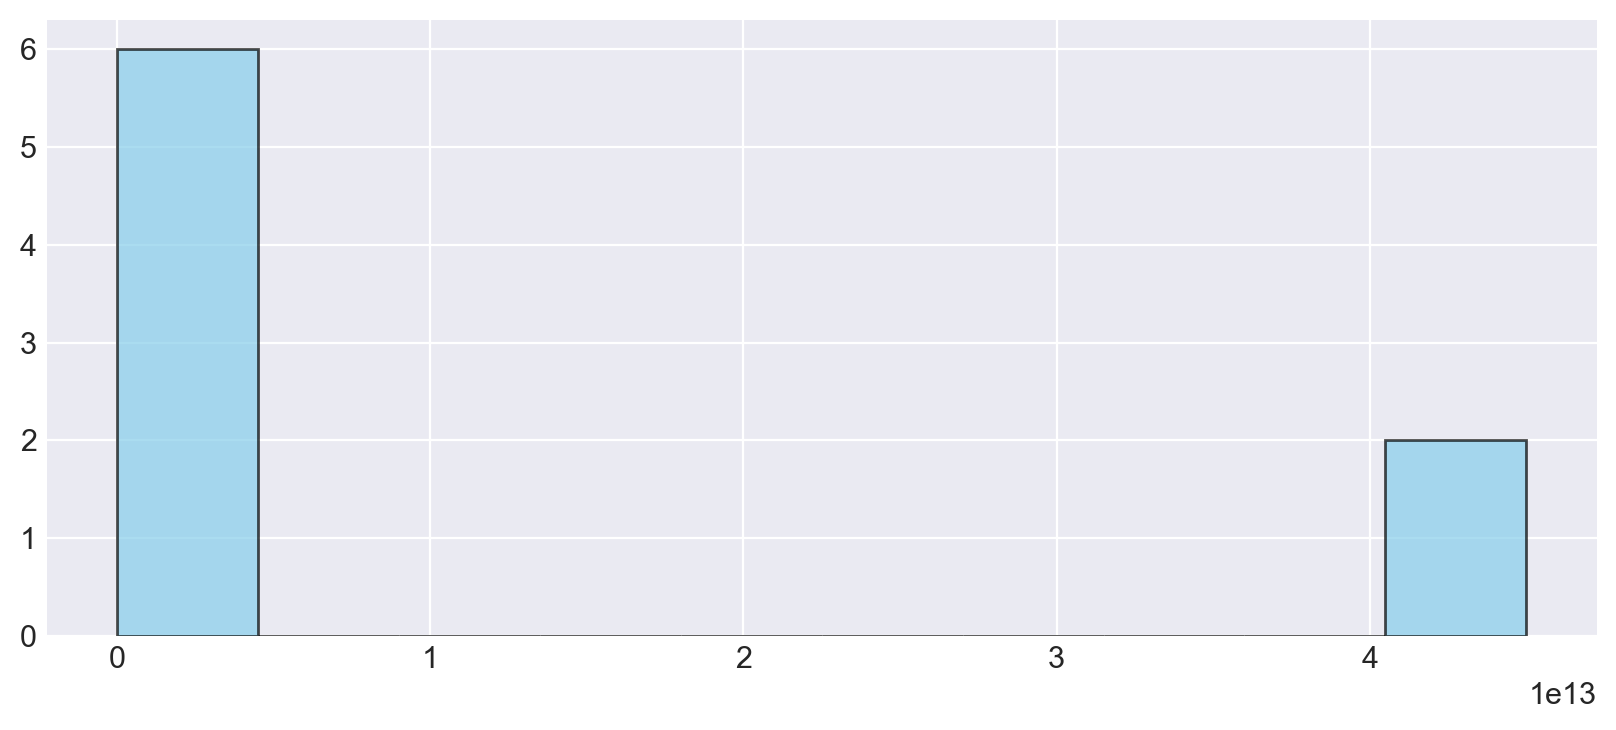

Objectives median/std: 1538.35 / 19485571579479.86
Number of starts within 10% of best objective: 3 out of 8


In [334]:
# Plot histogram
plt.hist(objectives, bins=10, alpha=0.7, color='skyblue', edgecolor='black')
plt.show()

# Print summary statistics
print(f"Objectives median/std: {np.median(objectives):.2f} / {np.array(objectives).std():.2f}")

# How many starts found a solution within 10% of the best objective?
fmin, fmax = res_ms.fun * 0.9, res_ms.fun * 1.1
count_within_10pct = sum(fmin <= obj <= fmax for obj in objectives)
print(f"Number of starts within 10% of best objective: {count_within_10pct} out of {n_starts}")

In [335]:
# Print parameter comparison and objective value
df_ms = pd.DataFrame({
    'Estimated Value (Multi-start)': np.exp(res_ms.x),
    'Ratio (Multi-start) (Est/True)': np.exp(res_ms.x) / np.exp(theta_true),
})

df_ms = pd.concat((df_de, df_ms), axis=1)
print(df_ms.to_string(index=False))


print("\nLBFGS-B good start functional: ", res_good.fun)
print("Least-Squares good start functional: ", res_ls.fun.mean())
print("Differential Evolution functional -> ", res_de.fun)
print("Multi-start Evolution functional -> ", res_ms.fun)

Parameter  True Value  Estimated Value  Ratio (Est/True)  Estimated Value (bad init)  Ratio (bad init) (Est/True)  Estimated Value (ls good init)  Ratio (ls good init) (Est/True)  Estimated Value (dif. evolution)  Ratio (dif. evolution) (Est/True)  Estimated Value (Multi-start)  Ratio (Multi-start) (Est/True)
      k12        0.60         0.572723          0.954539                    0.050000                     0.083333                        0.572723                         0.954539                          0.572723                           0.954539                       0.572723                        0.954539
      k21        0.30         0.293311          0.977704                    2.000000                     6.666667                        0.293311                         0.977704                          0.293311                           0.977704                       0.293311                        0.977704
       ke        0.15         0.150950          1.006333           

- ✅ Both local methods with good initial guesses and the global methods seemed to have landed in the same minimum.

### Task 4.3 — Visualise the loss landscape

Plot 2D slices of the objective function around the true parameters. Choose the pair $(k_{12}, k_{21})$ and the pair $(EC_{50}, n)$.

This demonstrates the non-convexity and the parameter interactions.

Computing landscape for k12 vs k21...


100%|██████████| 40/40 [00:48<00:00,  1.22s/it]


Computing landscape for EC50 vs n...


100%|██████████| 40/40 [00:49<00:00,  1.23s/it]


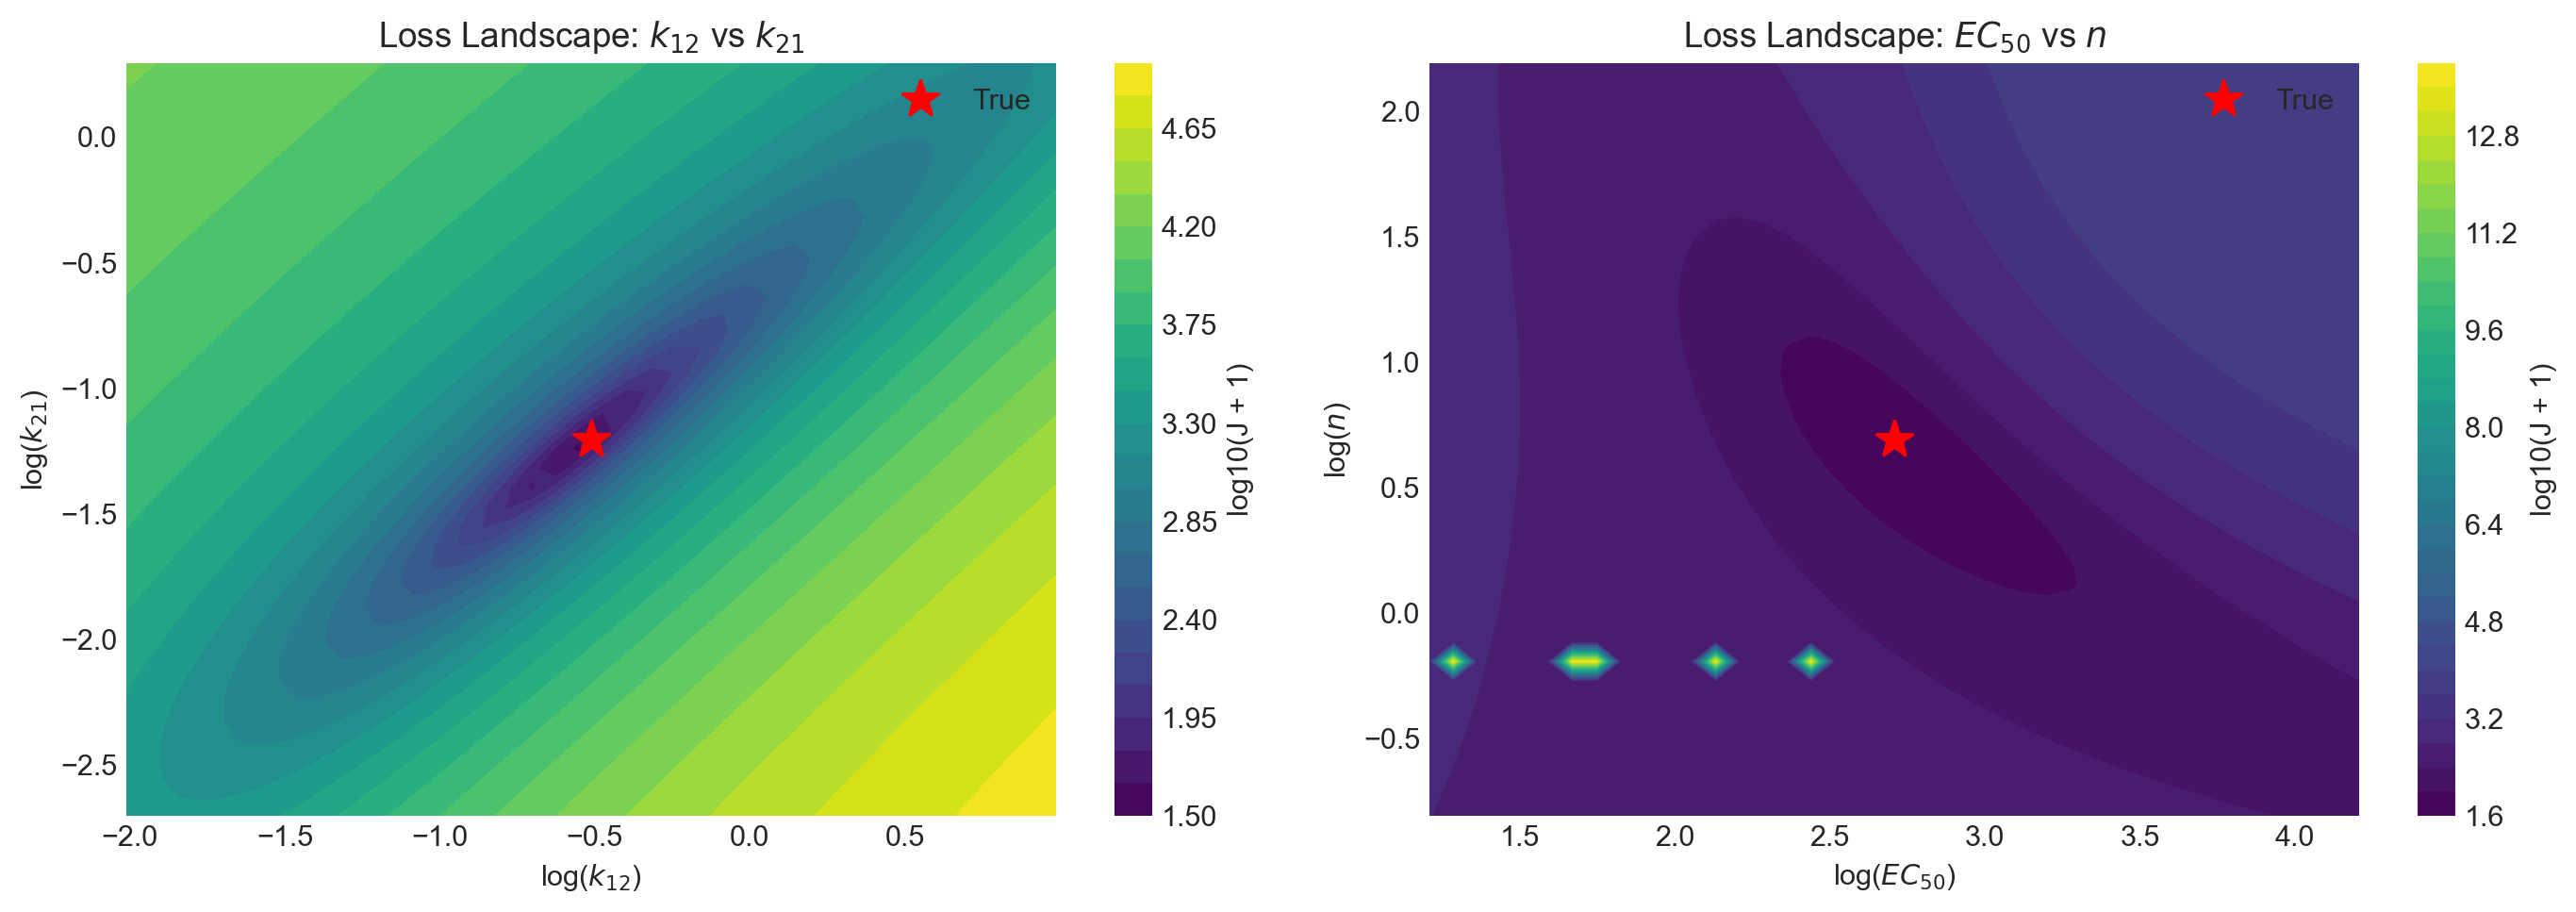

In [ ]:
# For each pair, create a 2D grid of parameter values (in log-space)
# At each grid point, set the two parameters to the grid values and all
# others to the true values, then evaluate the objective
# Plot as a filled contour (plt.contourf) with the true values marked

# Pair 1: log(k12) vs log(k21) — indices 0, 1
# Pair 2: log(EC50) vs log(n)  — indices 5, 6

from tqdm import tqdm

def landscape_2d(idx_x, idx_y, x_range, y_range, n_grid=60):
    """Evaluate objective on a 2D grid, varying params idx_x and idx_y."""
    xx = np.linspace(*x_range, n_grid)
    yy = np.linspace(*y_range, n_grid)
    Z = np.full((n_grid, n_grid), np.nan)

    for i, xv in tqdm(enumerate(xx), total=n_grid):
        for j, yv in enumerate(yy):
            theta = theta_true.copy()
            theta[idx_x] = xv
            theta[idx_y] = yv
            Z[j, i] = objective(theta)
    return xx, yy, Z


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pair 1: k12 vs k21
print("Computing landscape for k12 vs k21...")
xx1, yy1, Z1 = landscape_2d(0, 1,
    (theta_true[0]-1.5, theta_true[0]+1.5),
    (theta_true[1]-1.5, theta_true[1]+1.5), n_grid=40)
cs1 = axes[0].contourf(xx1, yy1, np.log10(Z1 + 1), levels=30, cmap='viridis')
axes[0].plot(theta_true[0], theta_true[1], 'r*', markersize=15, label='True')
axes[0].set_xlabel('log($k_{12}$)')
axes[0].set_ylabel('log($k_{21}$)')
axes[0].set_title('Loss Landscape: $k_{12}$ vs $k_{21}$')
axes[0].legend()
plt.colorbar(cs1, ax=axes[0], label='log10(J + 1)')

# Pair 2: EC50 vs n
print("Computing landscape for EC50 vs n...")
xx2, yy2, Z2 = landscape_2d(5, 6,
    (theta_true[5]-1.5, theta_true[5]+1.5),
    (theta_true[6]-1.5, theta_true[6]+1.5), n_grid=40)
cs2 = axes[1].contourf(xx2, yy2, np.log10(Z2 + 1), levels=30, cmap='viridis')
axes[1].plot(theta_true[5], theta_true[6], 'r*', markersize=15, label='True')
axes[1].set_xlabel('log($EC_{50}$)')
axes[1].set_ylabel('log($n$)')
axes[1].set_title('Loss Landscape: $EC_{50}$ vs $n$')
axes[1].legend()
plt.colorbar(cs2, ax=axes[1], label='log10(J + 1)')

plt.tight_layout()
plt.show()

###  Verification
- The loss landscapes contains elongated valleys (parameter compensation) and multiple basins.
- Recovered K12, K21, KE and n values are within 10% of the true solution.

---

## Section 5 — Sensitivity Analysis

### Task 5.1 — Local sensitivity: the Jacobian via finite differences

Compute the Jacobian of the model outputs with respect to the 7 parameters at the true parameter values. Visualise which parameters affect which outputs most strongly.

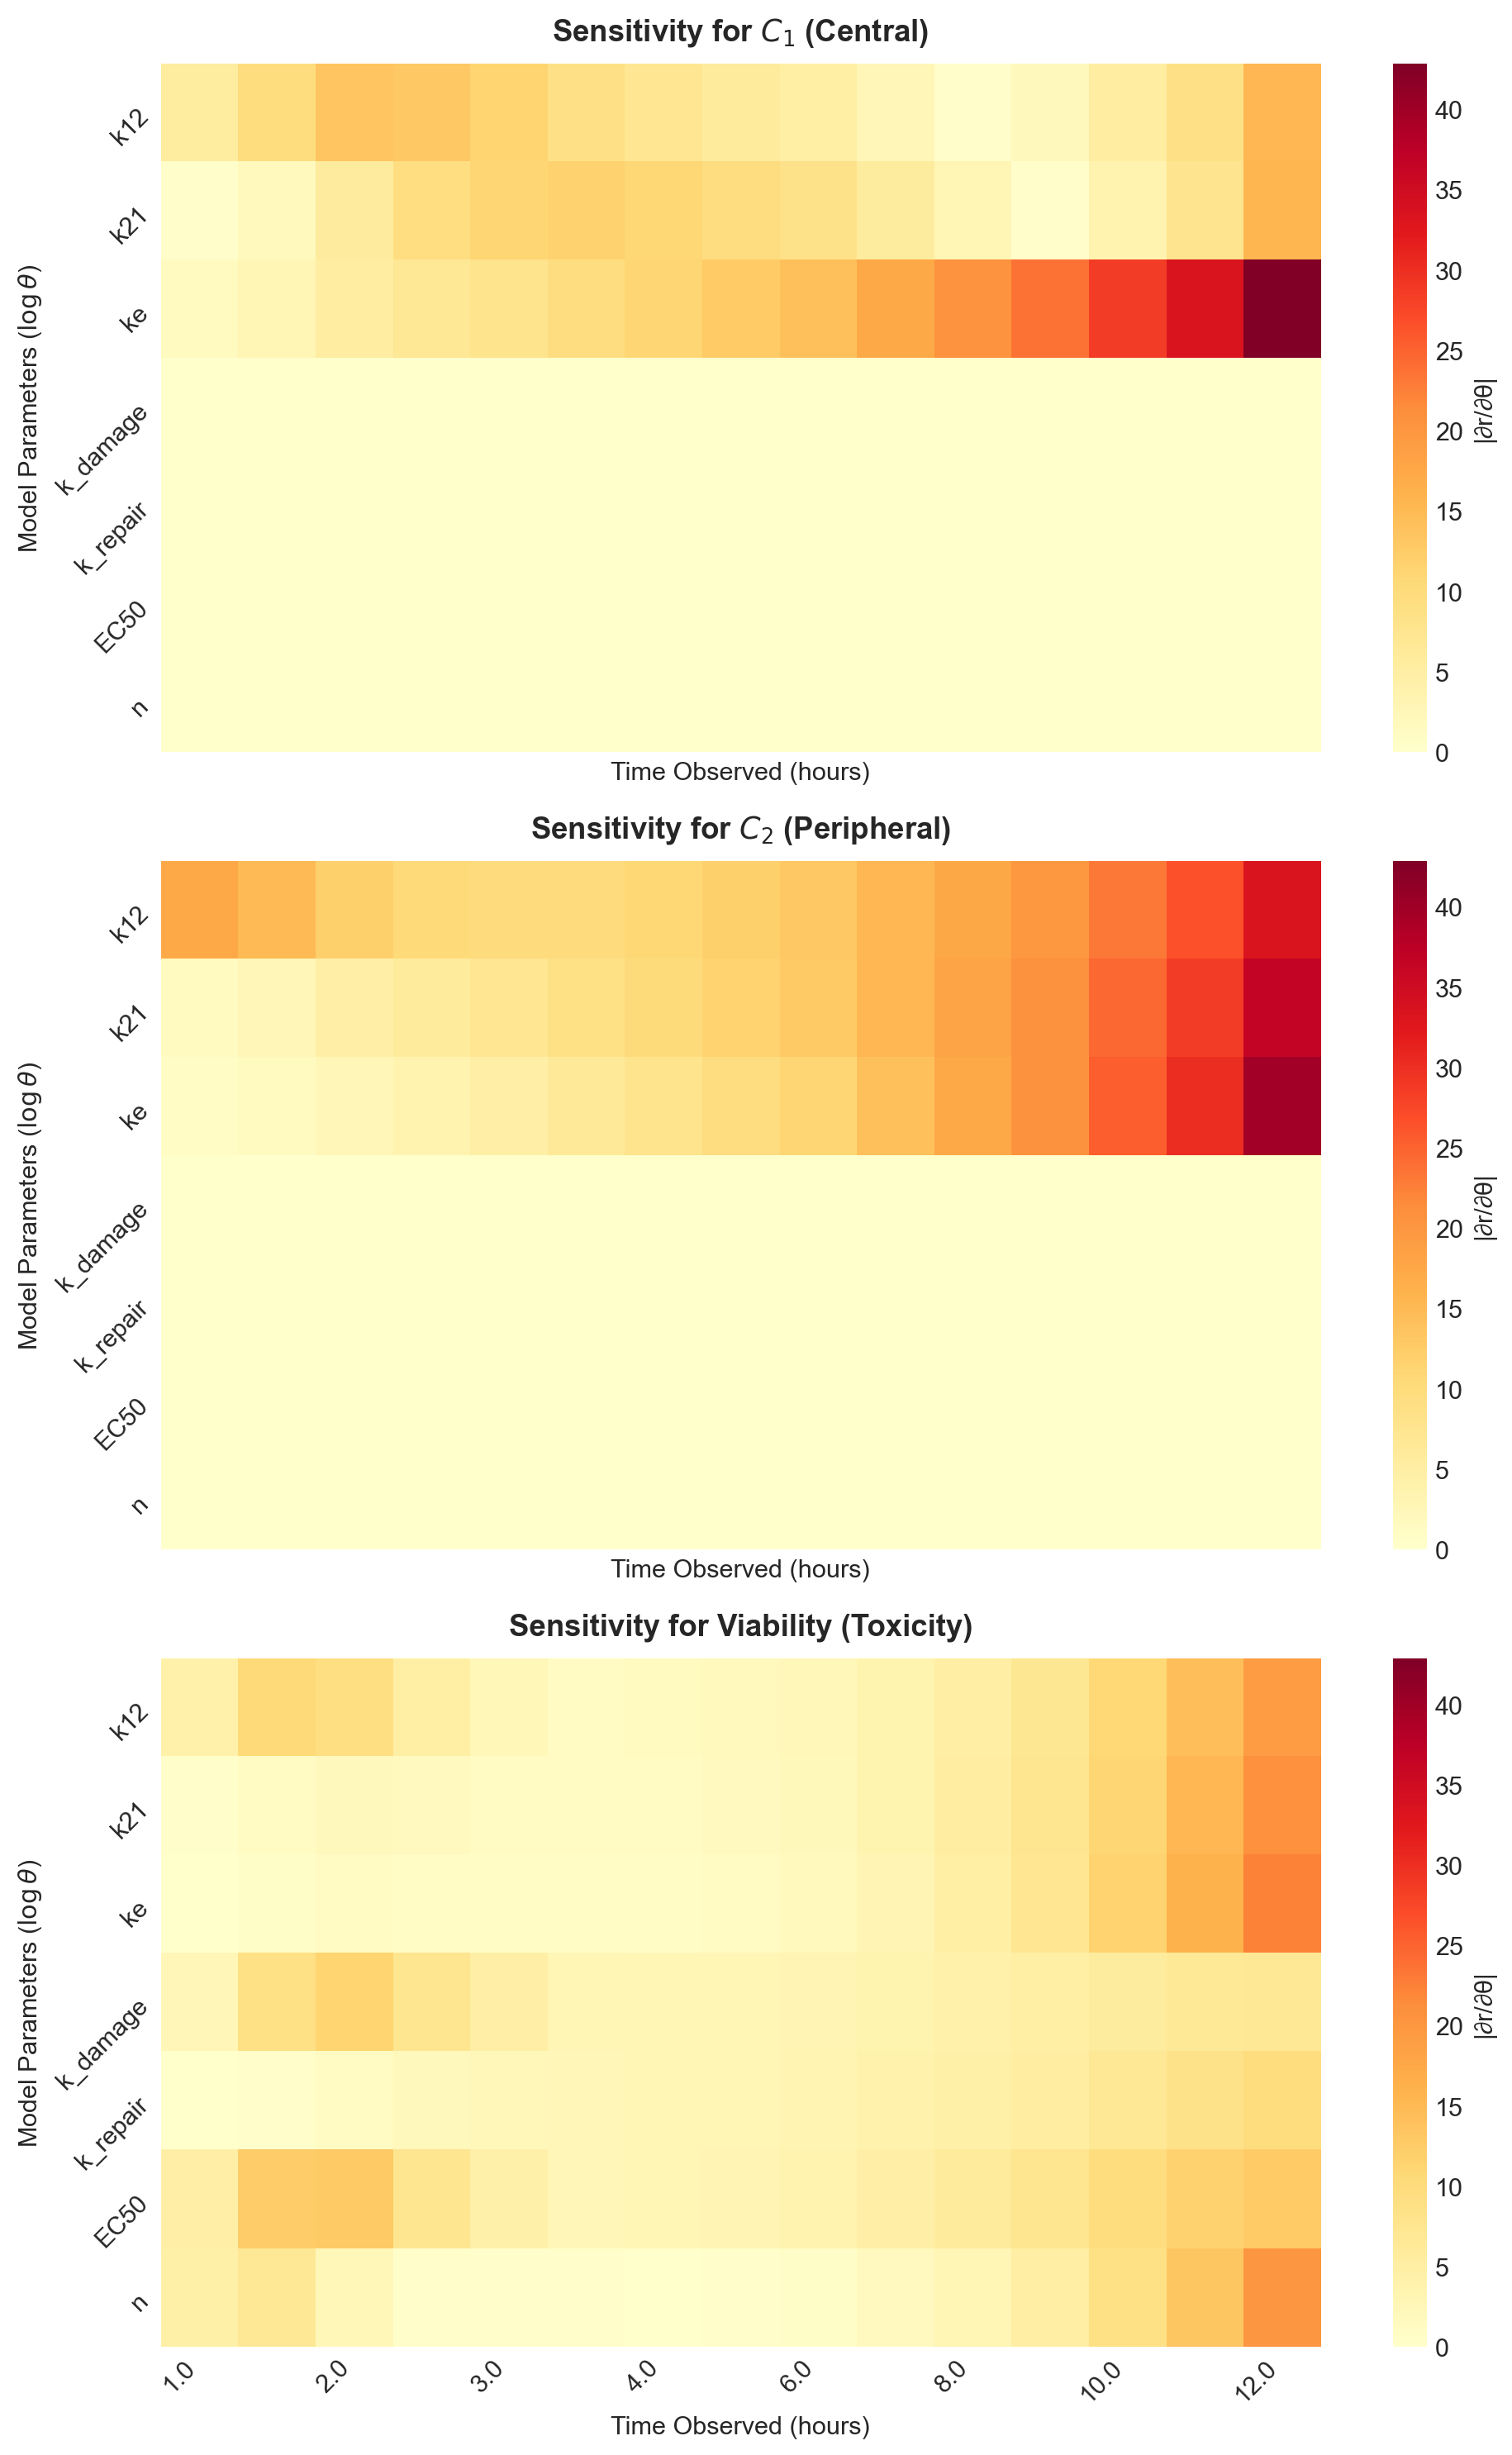

In [336]:
def compute_jacobian(log_theta, epsilon=1e-5):
    """
    Compute the Jacobian of the model outputs w.r.t. log-parameters
    using central finite differences.

    Parameters
    ----------
    log_theta : array, shape (7,)
    epsilon : float — finite difference step size

    Returns
    -------
    J : array, shape (n_obs * 3, 7) — Jacobian matrix
    """
    n_params = len(log_theta)
    f0 = residuals(log_theta)  # baseline residuals for each observation (3 per time point) total 45
    n_outputs = len(f0)
    J = np.zeros((n_outputs, n_params))

    for j in range(n_params):
        # Perturb log_theta[j] by +epsilon and -epsilon
        theta_plus = log_theta.copy()
        theta_plus[j] += epsilon

        theta_minus = log_theta.copy()
        theta_minus[j] -= epsilon

        # Evaluate residuals at both perturbed points
        f_plus = residuals(theta_plus)
        f_minus = residuals(theta_minus)

        # Compute central difference:
        J[:, j] = (f_plus - f_minus) / (2 * epsilon)

    return J


# 1. Compute and reshape the Jacobian
J = compute_jacobian(theta_true)
n = len(t_obs)

# Slice the 45 rows into 3 blocks of 15
J_C1 = np.abs(J[0:n, :])
J_C2 = np.abs(J[n:2*n, :])
J_V  = np.abs(J[2*n:3*n, :])

# 2. Setup Plotting
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
objs = [J_C1, J_C2, J_V]
titles = ['$C_1$ (Central)', '$C_2$ (Peripheral)', 'Viability (Toxicity)']

names_short = ['k12', 'k21', 'ke', 'k_damage', 'k_repair', 'EC50', 'n']

# 3. Iterate through subplots
for i, ax in enumerate(axes):
    # Use 'nearest' to keep the grid blocks sharp
    im = ax.imshow(objs[i].T, aspect='auto', cmap='YlOrRd', interpolation='nearest', vmin=0, vmax=J.max())
    
    ax.set_title(f'Sensitivity for {titles[i]}', fontweight='bold', pad=10)
    ax.set_xlabel('Time Observed (hours)')
    ax.set_xticklabels(t_obs, rotation=45, ha='right')
    
    # Add a colorbar for each to handle different scales
    fig.colorbar(im, ax=ax, label='|∂r/∂θ|')
    ax.grid(False)

    # 4. Global formatting
    ax.set_yticks(range(7))
    ax.set_yticklabels(names_short, rotation=45, ha='right')
    ax.set_ylabel('Model Parameters ($\log \\theta$)')

plt.tight_layout()
plt.show()

- ✅ Concentrations are only sensitive to parameters K12, K21 and KE. This makes sense as only these parameters compose the concetration ODEs
- ✅ C1 concentration is largely influenced by KE, but only at the later observed times
- ✅ C2 concentration is approximately equally influenced by the parameters, with stronger influence at later observed times.
- ✅ Vitality is mildly sensitive to all parameters, given that the toxicity model contains K_damage, K_repair, EC50 and n, as well as depending on C1 and C2 

### Task 5.2 — Morris screening (global sensitivity)

Use SALib to run Morris screening. Identify which parameters are most influential and which could be safely fixed.

> **Note:** SALib should be available. If not, install with `pip install SALib`.

Total samples: 400, Valid evaluations: 322

Parameter            μ*          σ Interpretation
-------------------------------------------------------
k12              0.6796     0.8411 Important
k21              0.7483     0.9275 Important
ke               0.7674     0.9820 Important
k_damage         0.7599     0.8057 Important
k_repair         0.9666     0.8756 Important
EC50             0.5684     0.8345 Important
n                0.6982     0.9426 Important


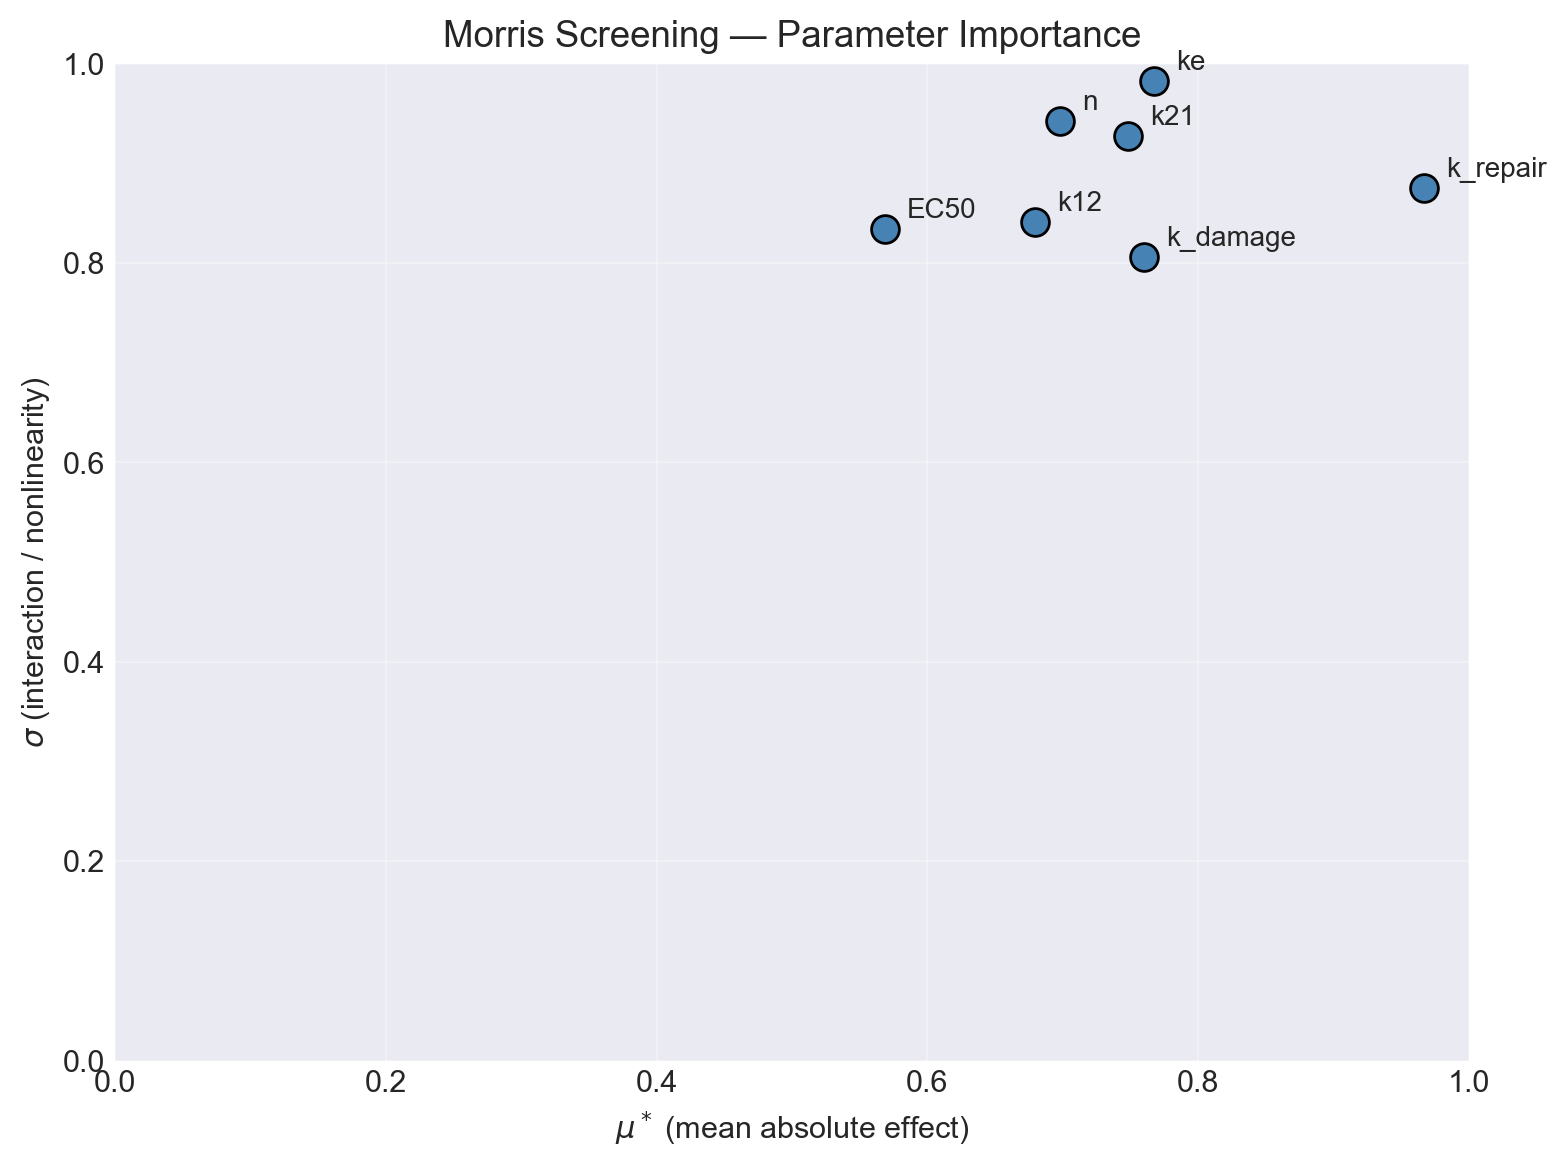

In [365]:
# If SALib is not installed, uncomment the next line:
# !pip install SALib
try:
    from SALib.sample import morris as morris_sample
    from SALib.analyze import morris as morris_analyze
except ImportError:
    print("SALib is not installed. Please install it to run the sensitivity analysis.")

# Define the problem for SALib
problem = {
    'num_vars': 7,
    'names': names_short,
    'bounds': [[-3, 3]] * 7  # log-space bounds
}


def model_for_sa(log_theta_row):
    """Run the model and return final viability at t=48h."""
    theta = np.exp(log_theta_row)
    k12, k21, ke, k_damage, k_repair, EC50, n = theta
    params = {
        'k12': k12, 'k21': k21, 'ke': ke,
        'V1': V1_fixed, 'V2': V2_fixed,
        'k_damage': k_damage, 'k_repair': k_repair,
        'Emax': Emax_fixed, 'EC50': EC50, 'n': n
    }
    try:
        sol = solve_ivp(
            fun=lambda t, y: coupled_rhs(t, y, params),
            t_span=(0, 48), y0=[dose / V1_fixed, 0.0, 0.0],
            t_eval=[48], method='Radau', rtol=1e-6, atol=1e-8
        )
        if sol.success and sol.y.shape[1] > 0:
            return 1 - sol.y[2, -1]
        return np.nan
    except Exception:
        return np.nan


# Generate Morris samples: X = morris_sample.sample(problem, N=50, seed=42)
# This will create a 50x7 matrix of parameter sets in log-space according to the Morris sampling strategy
# The Morris sample strategy works by creating trajectories in the parameter space where one parameter is
# varied at a time, allowing for efficient estimation of sensitivity indices with fewer model evaluations
# compared to full factorial designs.
X = morris_sample.sample(problem, N=50, seed=42)

# # Evaluate model at each sample: Y = np.array([model_for_sa(x) for x in X])
Y = np.array([model_for_sa(x) for x in X])
valid = ~np.isnan(Y)
X_valid = X[valid]
Y_valid = Y[valid]

print(f"Total samples: {len(Y)}, Valid evaluations: {valid.sum()}")

# Analyse: Si_m = morris_analyze.analyze(problem, X, Y)
Si_m = morris_analyze.analyze(problem, X_valid[:-2], Y_valid[:-2], )

# # Print the results: Si_m['mu_star'] (mean absolute effect) and Si_m['sigma'] (interaction)
# print("Morris Sensitivity Analysis Results:")
# for name, mu_star, sigma in zip(Si_m['names'], Si_m['mu_star'], Si_m['sigma']):
#     print(f"{name}: mu* = {mu_star:.4f}, sigma = {sigma:.4f}")

# Print results
print(f"\n{'Parameter':<12} {'μ*':>10} {'σ':>10} {'Interpretation'}")
print('-' * 55)
for i, name in enumerate(names_short):
    mu_star = Si_m['mu_star'][i]
    sigma = Si_m['sigma'][i]
    if mu_star > 0.1:
        interp = "Important"
    elif mu_star > 0.01:
        interp = "Moderate"
    else:
        interp = "Negligible"
    print(f"{name:<12} {mu_star:>10.4f} {sigma:>10.4f} {interp}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Si_m['mu_star'], Si_m['sigma'], s=100, c='steelblue', edgecolors='black')
for i, name in enumerate(names_short):
    ax.annotate(name, (Si_m['mu_star'][i], Si_m['sigma'][i]),
                textcoords='offset points', xytext=(8, 4), fontsize=10)
ax.set_xlim(0, 1.)
ax.set_ylim(0, 1.)
ax.set_xlabel('$\\mu^*$ (mean absolute effect)')
ax.set_ylabel('$\\sigma$ (interaction / nonlinearity)')
ax.set_title('Morris Screening — Parameter Importance')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- ✅ From Morris analysis, KE is the most correlated parameter, and K_repair the most influential. Further experiments should focus on gathering information that constraints these results.
- ✅ All parameters have significant effect and correlation, leading to a very non-linear landscape 
- ✅ K12 and EC50 have the lowest influences on the model and could be kept fixed at a rough approximate to save computational time while minimising model innacuracies.


### Task 5.3 — Sobol Indices (variance distribution)

Use SALib to run Sobol Indices to compute the influence of each parameter on model variance.


In [379]:
try:
    from SALib.sample import saltelli as saltelli_sample
    from SALib.analyze import sobol as sobol_analyze
except ImportError:
    print("SALib is not installed. Please install it to run the sensitivity analysis.")


# Generate the Sample Matrix
# N=512 is a solid starting point for 7 variables
# We ran only for 25 to save time in this environment, but for a real analysis,
# you would want to use at least 512 or more samples to get stable estimates of the Sobol indices.
X = saltelli_sample.sample(problem, 50)

# The Parallel Loop
print(f"Starting {len(X)} simulations on all cores...")

# n_jobs=-1 uses all available CPU cores
results = Parallel(n_jobs=-1, backend='threading')(
    delayed(model_for_sa)(p) for p in X
)

Y = np.array(results)
Y_filled = np.where(np.isnan(Y), np.nanmean(Y), Y)  # Replace NaNs with mean for analysis

Si_s = sobol_analyze.analyze(problem, Y_filled)

Si_s

Starting 800 simulations on all cores...


{'S1': array([-0.00694078, -0.01821288, -0.00905262,  0.18339977,  0.22372825,
        -0.0720033 , -0.01312271]),
 'S1_conf': array([0.10537924, 0.19788069, 0.20616296, 0.3150711 , 0.224973  ,
        0.08620337, 0.057979  ]),
 'ST': array([0.14037827, 0.33264871, 0.51381287, 0.23806722, 0.3696913 ,
        0.01513862, 0.23182911]),
 'ST_conf': array([0.13733693, 0.20299993, 0.33920961, 0.16064144, 0.21246287,
        0.01393024, 0.21029638]),
 'S2': array([[        nan, -0.09023185, -0.04780583,  0.05348072,  0.05596409,
         -0.10425755, -0.10550166],
        [        nan,         nan,  0.19243442,  0.29832588,  0.23324016,
          0.19973311,  0.04740697],
        [        nan,         nan,         nan,  0.05858791, -0.04988074,
          0.01763057,  0.08147222],
        [        nan,         nan,         nan,         nan, -0.17133314,
         -0.10546075,  0.0149352 ],
        [        nan,         nan,         nan,         nan,         nan,
         -0.0783451 , -0.034585

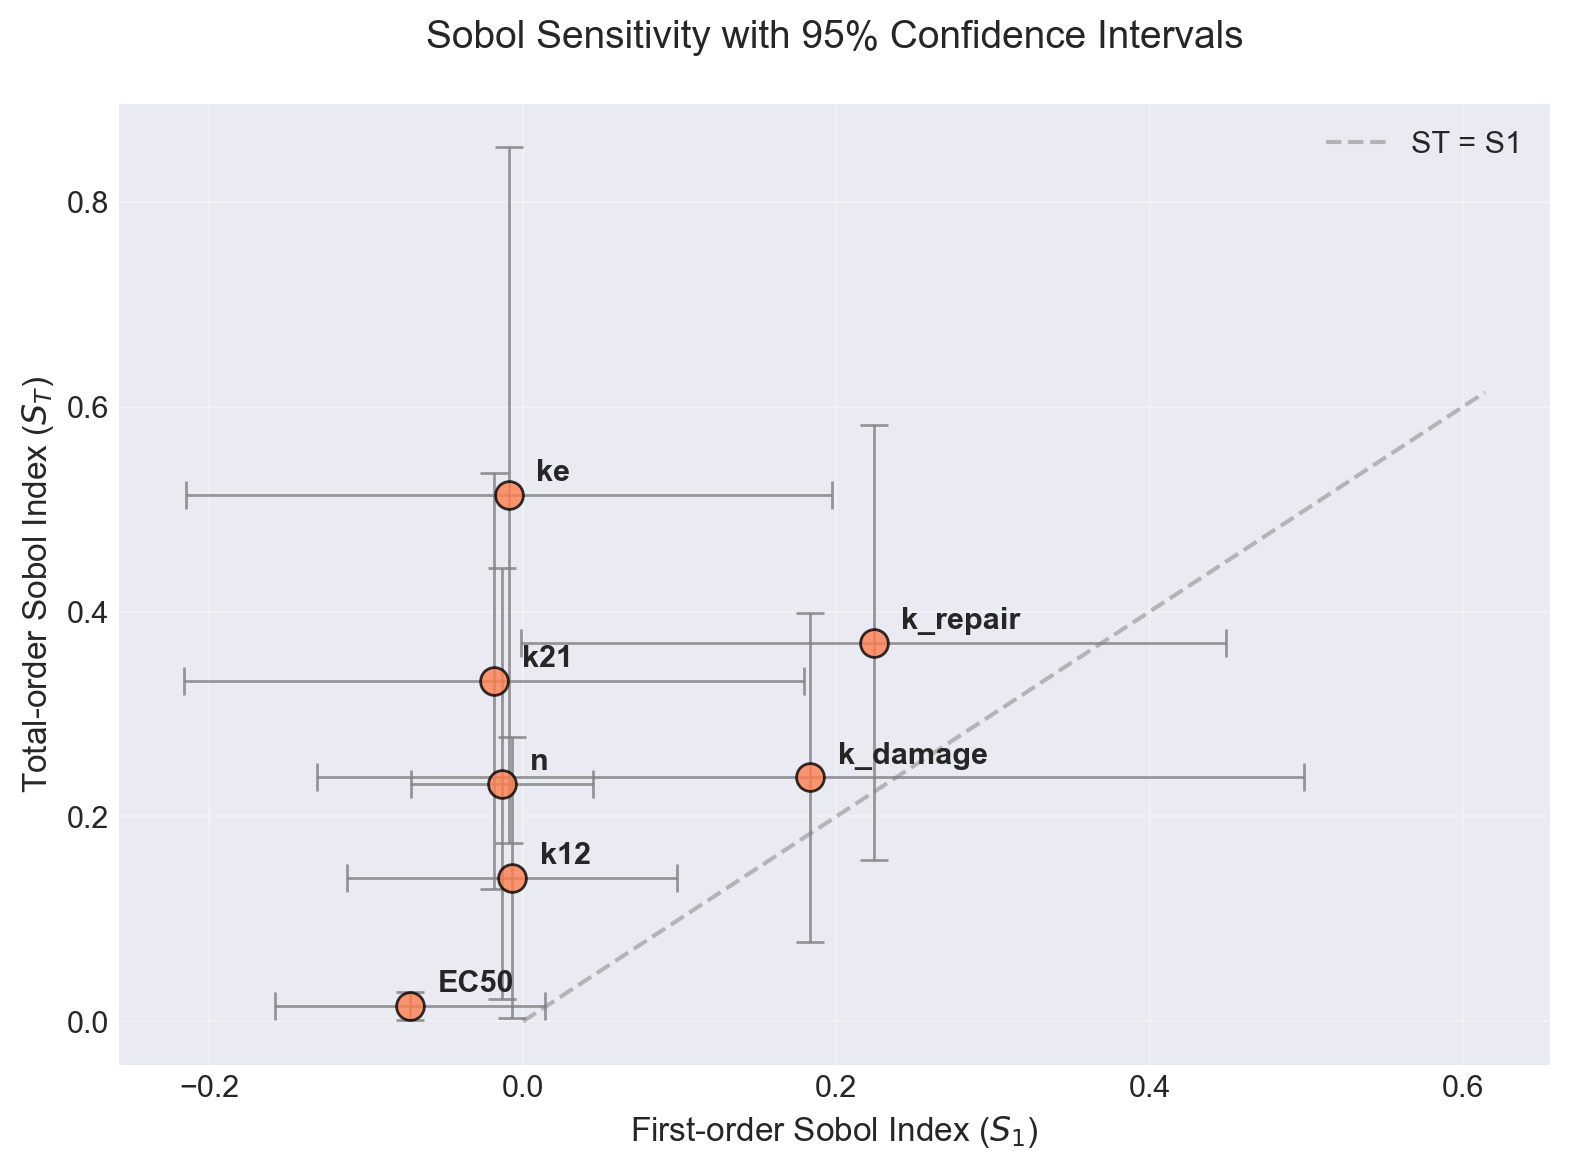

In [380]:
S1 = Si_s['S1']  # First-order indices
ST = Si_s['ST']  # Total-order indices

# plot S1 vs ST
fig, ax = plt.subplots(figsize=(8, 6))
# We use errorbar instead of scatter
# xerr and yerr take the confidence interval values (e.g., Si['S1_conf'])
ax.errorbar(S1, ST, 
            xerr=Si_s['S1_conf'], 
            yerr=Si_s['ST_conf'], 
            fmt='o',            # 'o' means circular markers
            capsize=5,          # Adds the little "caps" to the ends of the bars
            markersize=10, 
            color='coral', 
            ecolor='gray',     # Color of the error bars
            elinewidth=1,       # Thickness of the error bars
            markeredgecolor='black',
            alpha=0.8)

# Annotate the names
for i, name in enumerate(names_short):
    ax.annotate(name, (S1[i], ST[i]),
                textcoords='offset points', 
                xytext=(10, 5), 
                fontsize=11,
                fontweight='bold')

# Add a diagonal reference line (ST is always >= S1)
limit = max(max(S1), max(ST)) + 0.1
ax.plot([0, limit], [0, limit], linestyle='--', color='gray', alpha=0.5, label='ST = S1')

ax.set_xlabel('First-order Sobol Index ($S_1$)', fontsize=12)
ax.set_ylabel('Total-order Sobol Index ($S_T$)', fontsize=12)
ax.set_title('Sobol Sensitivity with 95% Confidence Intervals', fontsize=14, pad=20)

# ax.set_xlim(left=-0.05) # Show a bit of the negative noise if it exists
# ax.set_ylim(bottom=-0.05)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

- ✅ For Sobol indices, S1 represents the isolated percentage of the model variance that is explained by the parameter. ST represents the total influence of the model parameter, taking also into account coupling effects. The effective influence from coupling only, therefore, is taken as ST-S1.
- ✅ The dashed grey line represents where ST=S1. Points on that line have only direct influence on the variance without coupling effects.
- ✅ With only 50 Samples the Sobol Indices have low confidence and cannot be used for accurate interpretation.
- ✅ The choice of 50 samples here is purely a computational one for this exercise.
- ✅ Supposing that these values are accurate, they would tell the story: K_repair is mostly influential parameter (agrees with the Morris Screening), with an individual contribution (~24%).
- ✅ K12 and EC50 are the safest parameters to keep fixed, as they have little influence overall. This also agrees with the Morris Screening
- ✅ KE has a large coupling influence but not an independent one.

---

## Section 6 — Parameter Identifiability & the Fisher Information Matrix

### Task 6.1 — Compute the FIM and approximate parameter confidence intervals

Use the Jacobian from Section 5 to compute the Fisher Information Matrix and derive approximate 95% confidence intervals via the Cramér-Rao bound.

In [340]:
# Compute the FIM:  F = J.T @ J
F = J.T @ J # (The residuals are already weighted by 1/sigma, so W is implicitly included)

# Rank and condition number
rank_F = np.linalg.matrix_rank(F)
cond_F = np.linalg.cond(F)
print(f"FIM Rank: {rank_F} / {F.shape[0]}, Condition Number: {cond_F:.2f}")

# Compute the covariance matrix as the inverse of F. If F is singular or near-singular, use the pseudo-inverse.
if rank_F < F.shape[0]:
    Cov = np.linalg.pinv(F)
    print("FIM is singular or near-singular. Using pseudo-inverse for covariance.")
else:
    Cov = np.linalg.inv(F)

# Extract standard errors: se = np.sqrt(np.diag(Cov))
se_log = np.sqrt(np.diag(Cov))

# Compute 95% CI in log-space: theta ± 1.96 * se


print(f"\n{'Parameter':<12} {'True':>8} {'SE(log)':>8} {'CV(%)':>8} {'95% CI low':>12} {'95% CI high':>12} {'Identifiable?'}")
print('-' * 80)
for i, name in enumerate(names_short):
    tv = [i]
    se = se_log[i]
    # Coefficient of Variation (CV) in percentage: CV = 100 * se / |theta_true|. If theta_true is close to zero, CV can be very large, so we can set a threshold to avoid division by zero.
    cv = 100 * se / abs(theta_true[i]) if abs(theta_true[i]) > 1e-10 else np.inf
    # 95% CI in natural space: exp(theta ± 1.96 * se)
    ci_low  = np.exp(theta_true[i] - 1.96 * se)
    ci_high = np.exp(theta_true[i] + 1.96 * se)
    ident = "Yes" if cv < 50 else "POOR"
    print(f"{name:<12} {np.exp(theta_true[i]):>8.4f} {se:>8.4f} {cv:>8.1f} {ci_low:>12.4f} {ci_high:>12.4f} {ident}")

FIM Rank: 7 / 7, Condition Number: 9665.63

Parameter        True  SE(log)    CV(%)   95% CI low  95% CI high Identifiable?
--------------------------------------------------------------------------------
k12            0.6000   0.0371      7.3       0.5580       0.6452 Yes
k21            0.3000   0.0389      3.2       0.2780       0.3238 Yes
ke             0.1500   0.0127      0.7       0.1463       0.1538 Yes
k_damage       2.0000   0.4997     72.1       0.7511       5.3256 POOR
k_repair       0.1000   0.1246      5.4       0.0783       0.1277 Yes
EC50          15.0000   0.4600     17.0       6.0887      36.9536 Yes
n              2.0000   0.1689     24.4       1.4364       2.7847 Yes


### Task 6.2 — Correlation matrix

Compute and visualise the parameter correlation matrix from the covariance matrix. High correlations ($|\rho| > 0.9$) indicate parameter compensation — the two parameters cannot be estimated independently.

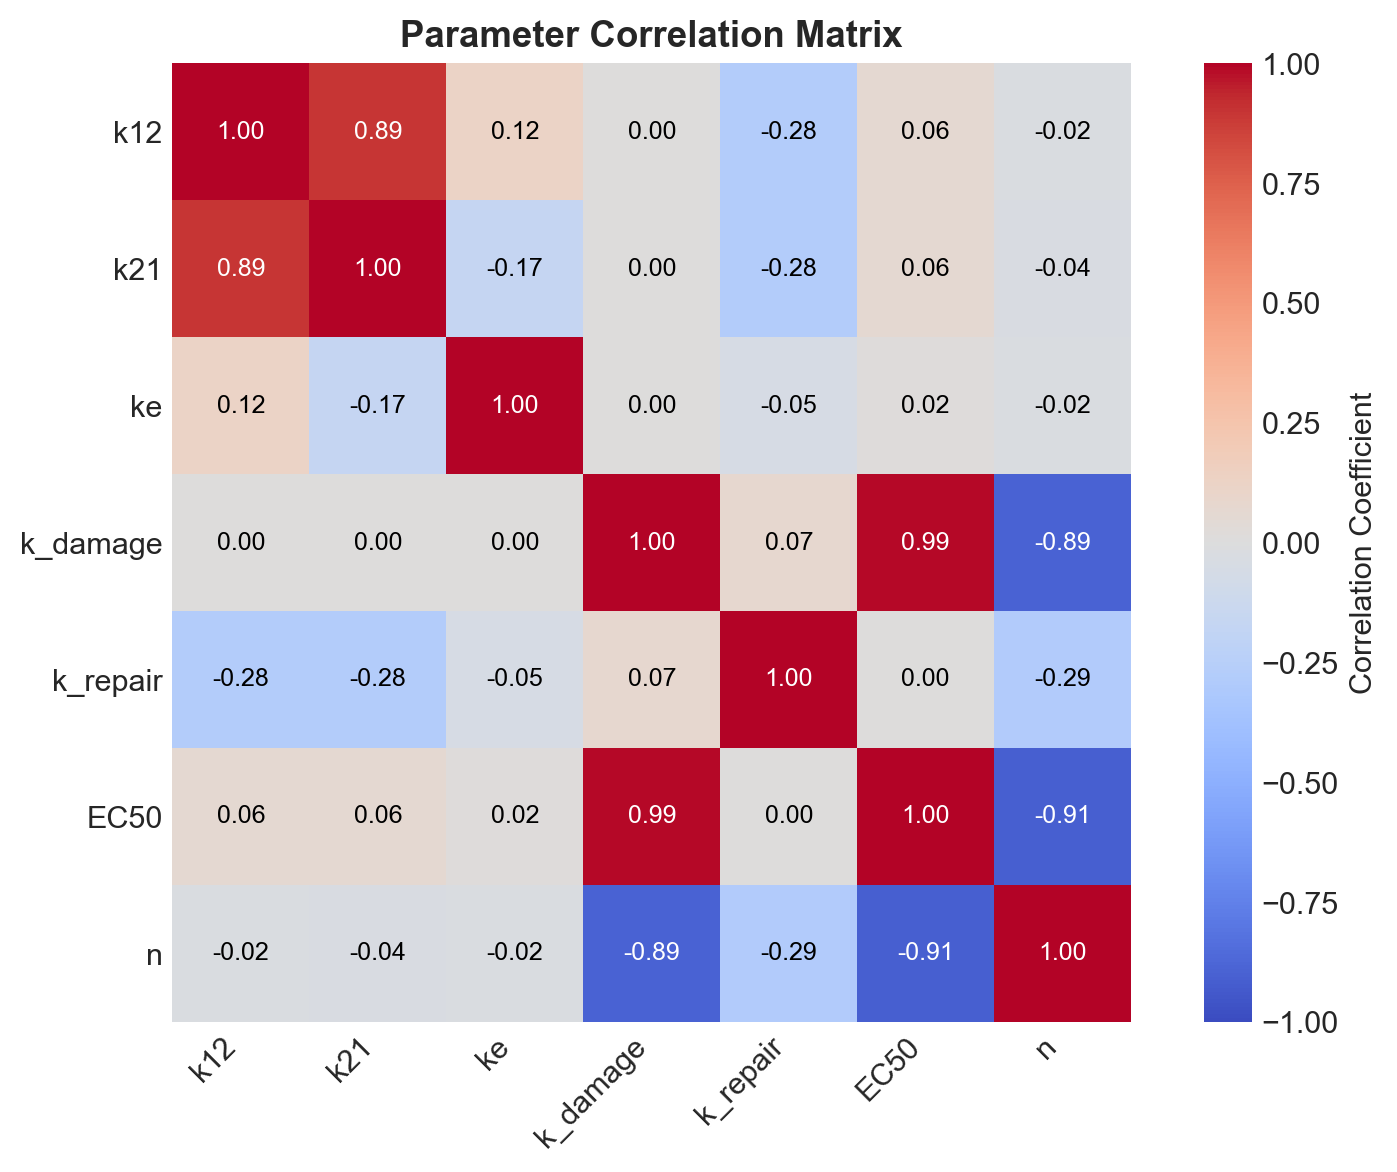

In [341]:
# Compute the correlation matrix from Cov:
corr = np.zeros_like(Cov)
for i in range(Cov.shape[0]):
    for j in range(Cov.shape[1]):
        corr[i,j] = Cov[i,j] / np.sqrt(Cov[i,i] * Cov[j,j])

# Plot as a heatmap with annotations
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(names_short)))
ax.set_yticks(range(len(names_short)))
ax.set_xticklabels(names_short, rotation=45, ha='right')
ax.set_yticklabels(names_short)
ax.set_title('Parameter Correlation Matrix', fontweight='bold')
ax.grid(False)
plt.colorbar(im, ax=ax, label='Correlation Coefficient')    
# Annotate the correlation values
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        text_color = 'white' if abs(corr[i,j]) > 0.5 else 'black'
        ax.text(j, i, f"{corr[i,j]:.2f}", ha='center', va='center', color=text_color, fontsize=9)
plt.tight_layout()
plt.show()



- ✅ Highly correlated parameters (positive or negative) implies low identifiability. It means the model struggles to differentiate between these two variables because they can compensate for one another (leading to narrow valleys). These are the ***under-determined*** parameters of the model.

- ✅ (K12, K21) at 0.89 -> compensation for preservation of mass
    - Solution: increase number of measurements to better constraint K12 and K21

- ✅ (EC50, K_damage) at 0.99, (n, K_damage) at -0.89 and (n, EC50) at -0.91 -> pratically indistinguishable. This occurs because when $C \ll EC_{50}$, the first term of the toxicity model simplifies to $\approx \frac{k_{damage}}{EC_{50}^n}$. The model fits for the ratio rather than parameters individually. In fact, these three parameters show the largest errors in our solution.
    - Solution: Add more timepoints near expected EC50 to better constraint the steepness and tipping point of the Hill function.
---

## Section 7 — ML Surrogates and Hybrid Modelling

### Task 7.1 — Generate training data for the surrogate

Sample the parameter space using Latin Hypercube Sampling and run the forward model at each sample point.

In [342]:
from scipy.stats import qmc

def generate_training_data(n_samples=500, seed=42):
    """
    Generate training data for the surrogate model.

    Returns
    -------
    X : array, shape (n_valid, 7) — log-parameter vectors
    Y : array, shape (n_valid, 3) — [max C1, max C2, final viability]
    """
    # Use Latin Hypercube instead of random sampling for better coverage of the parameter space
    sampler = qmc.LatinHypercube(d=7, seed=seed)
    samples_unit = sampler.random(n=n_samples)

    # Scale from [0,1] to bounds
    lb = np.array([-2.5] * 7)
    ub = np.array([2.5] * 7)
    X_all = qmc.scale(samples_unit, lb, ub)

    
    X_valid = []
    Y_valid = []

    for i in tqdm(range(n_samples)):
        log_theta = X_all[i]
        theta = np.exp(log_theta)
        k12, k21, ke, k_damage, k_repair, EC50, n = theta
        params = {
            'k12': k12, 'k21': k21, 'ke': ke,
            'V1': V1_fixed, 'V2': V2_fixed,
            'k_damage': k_damage, 'k_repair': k_repair,
            'Emax': Emax_fixed, 'EC50': EC50, 'n': n
        }

        # Solve the coupled ODE over [0, 48] hours, ignoring any failures
        # (e.g., due to stiff ODEs or non-physical parameters)
        try:
            res = solve_ivp(
                fun=lambda t, y: coupled_rhs(t, y, params),
                t_span=(0, 48), y0=[dose / V1_fixed, 0.0, 0.0],
                t_eval=np.linspace(0, 48, 100), method='Radau', rtol=1e-6, atol=1e-8
            )
            if not res.success:
                continue 
        except Exception:
            continue

        # Extract: max(C1), max(C2), final viability = 1 - D(48)
        C1, C2 = res.y[0], res.y[1]
        V = 1 - res.y[2][-1]  # final viability at t=48

        max_C1 = np.max(C1) # max C1 will always occur at t=0 since it's a bolus dose
        max_C2 = np.max(C2)

        # Append to X_valid and Y_valid (skip failed solves)
        X_valid.append(log_theta)
        Y_valid.append([max_C1, max_C2, V])

    return np.array(X_valid), np.array(Y_valid)


# Generate training data. Print shape and basic statistics.
X_train, Y_train = generate_training_data(n_samples=500)
print("Training data shape:")
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("\nBasic statistics for Y_train:")
print("Min:", np.min(Y_train, axis=0))
print("Max:", np.max(Y_train, axis=0))
print("Mean:", np.mean(Y_train, axis=0))
print("Std:", np.std(Y_train, axis=0))

100%|██████████| 500/500 [00:14<00:00, 33.51it/s]

Training data shape:
X_train: (403, 7)
Y_train: (403, 3)

Basic statistics for Y_train:
Min: [1.00000000e+02 2.73563236e-01 1.26732403e-02]
Max: [100.         32.4189888   1.       ]
Mean: [100.          12.06696162   0.79712769]
Std: [0.         9.33457611 0.29696664]


 94%|█████████▍| 15/16 [3:27:54<13:51, 831.66s/it]


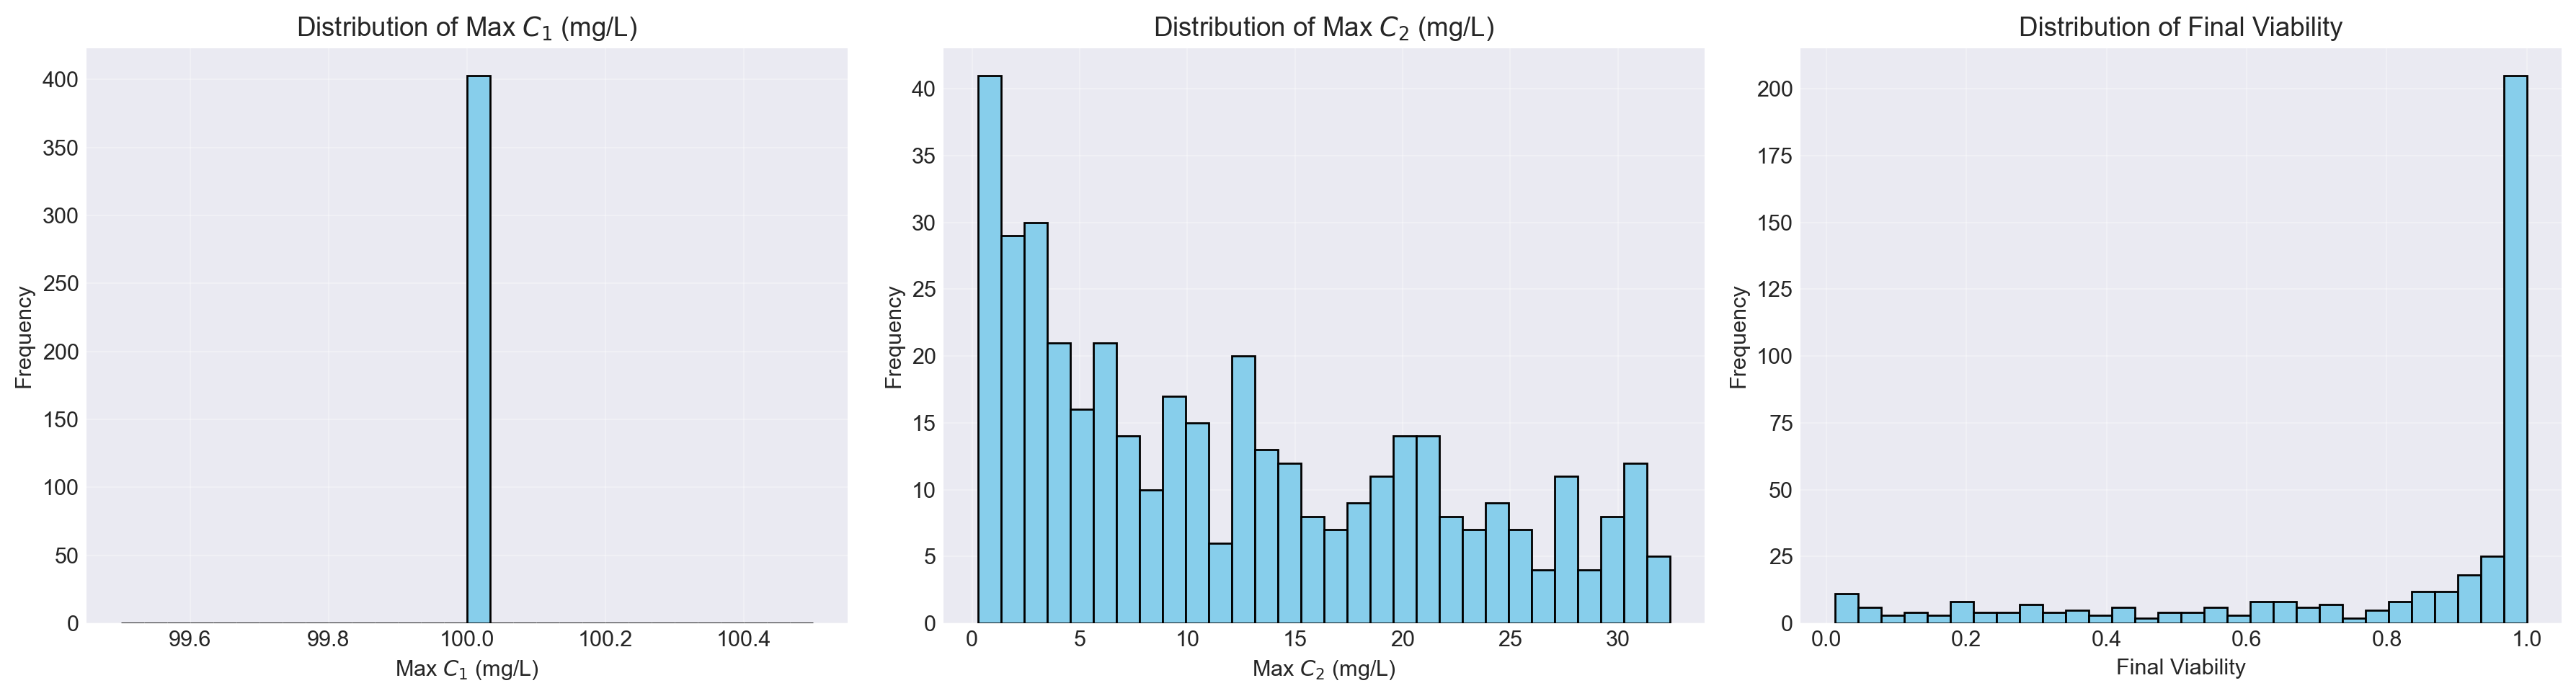

In [343]:
# Plot the training data distributions for each output variable
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Max $C_1$ (mg/L)', 'Max $C_2$ (mg/L)', 'Final Viability']
for i in range(3):
    axes[i].hist(Y_train[:, i], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {titles[i]}')
    axes[i].set_xlabel(titles[i])
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 7.2 — Train surrogate models

Train two surrogate models to predict **final viability** from the 7 log-parameters:
1. A gradient-boosted tree (using `sklearn.ensemble.GradientBoostingRegressor`)
2. A multi-layer perceptron (using `sklearn.neural_network.MLPRegressor`)

Evaluate both on a held-out test set using $R^2$ and RMSE.

In [344]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error

# Data and model are small, so we can run these without GPU acceleration.

# Split data
X_tr, X_te, Y_tr, Y_te = train_test_split(
    X_train, Y_train[:, 2],  # predict final viability only
    test_size=0.2, random_state=42
)

# Train a GradientBoostingRegressor
gbr = GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42,
    loss='squared_error', validation_fraction=0.1
)
gbr.fit(X_tr, Y_tr)


# Train an MLPRegressor
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64), max_iter=1000, early_stopping=True, random_state=42,
    solver='adam', learning_rate_init=0.001, validation_fraction=0.1
)
mlp.fit(X_tr_scaled, Y_tr)

print("Models trained.")

Models trained.


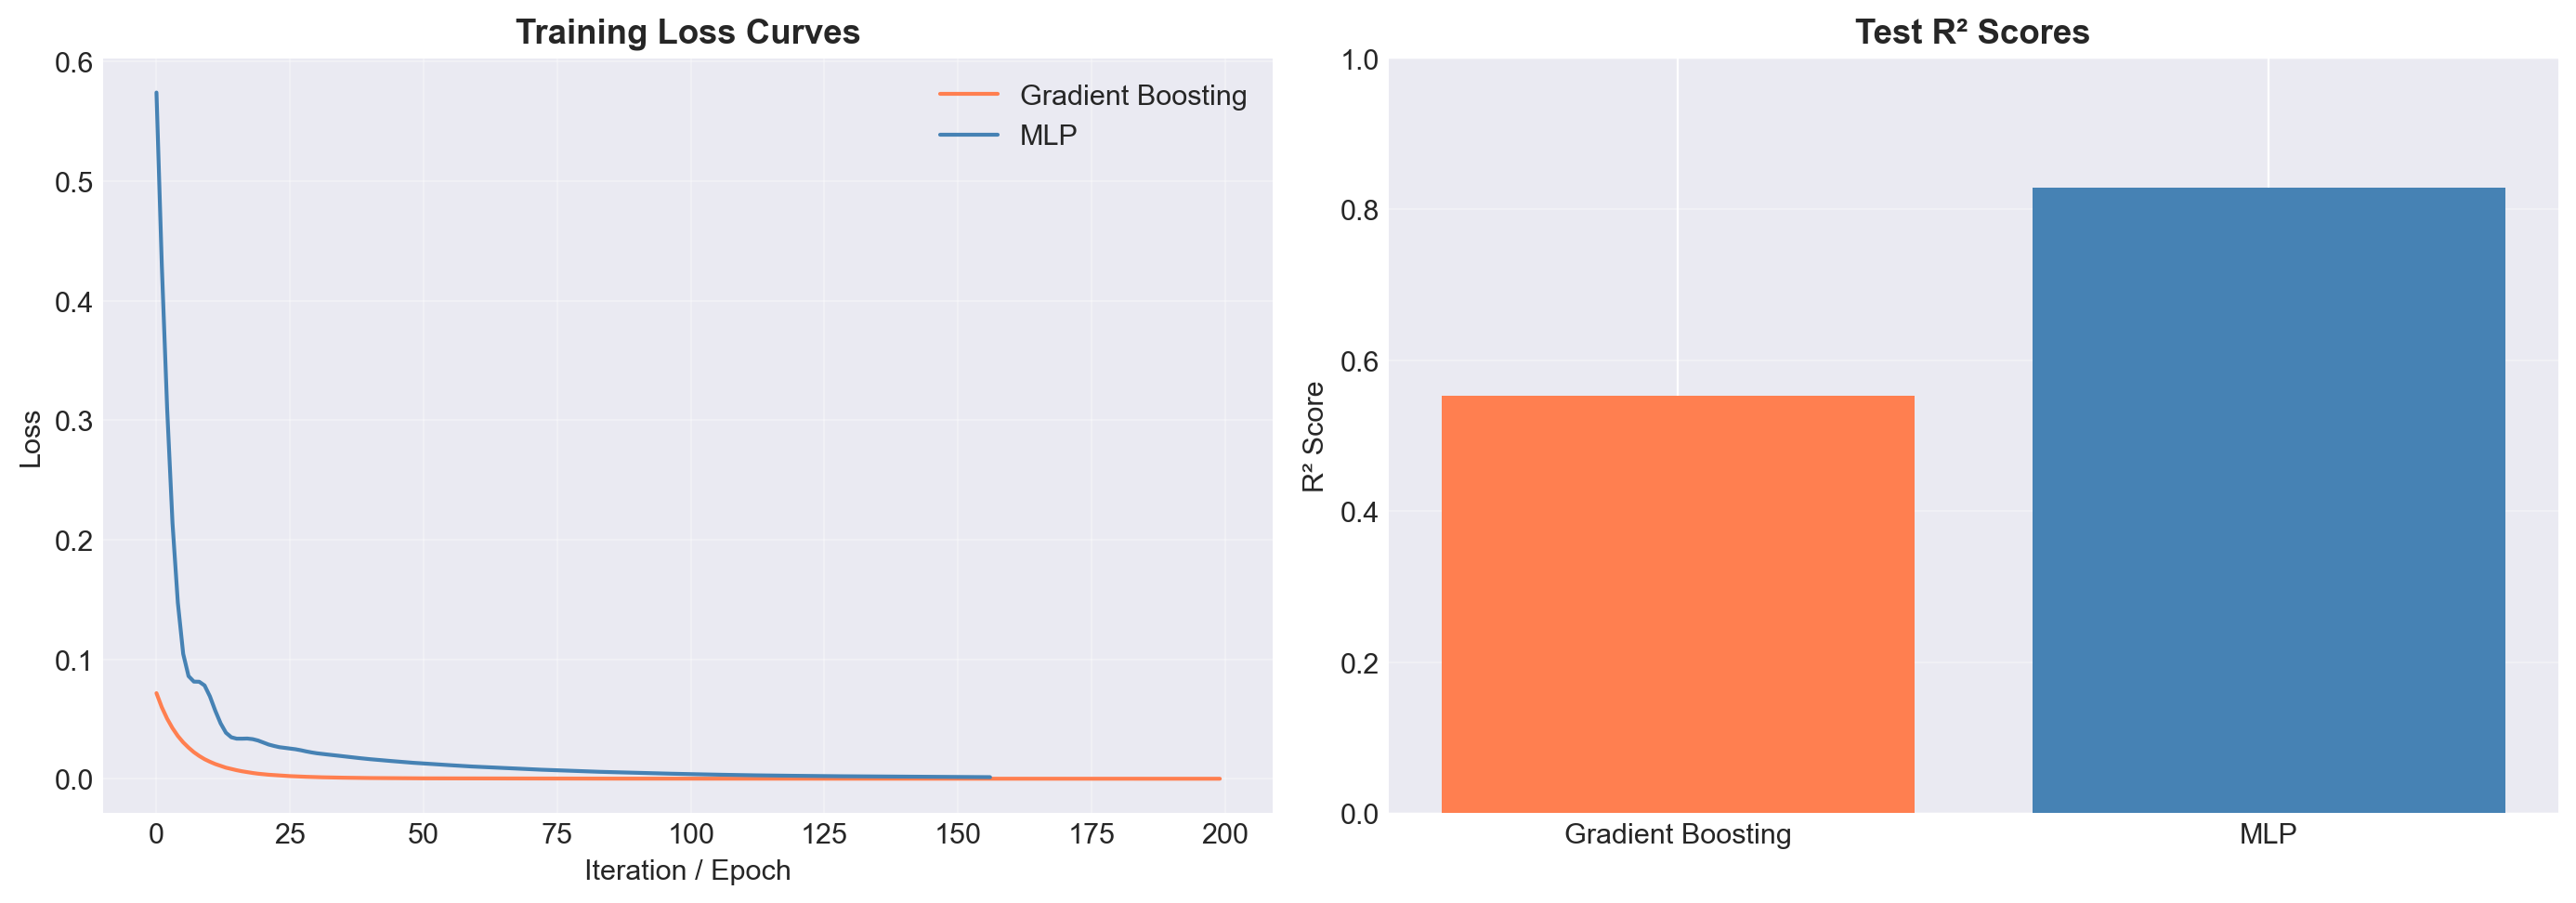

In [345]:
train_losses_gbr = gbr.train_score_
test_scores_gbr = gbr.score(X_te, Y_te)  # R² on test set at each stage

train_losses_mlp = mlp.loss_curve_
test_scores_mlp = mlp.score(X_te_scaled, Y_te)  # R² on test set at each stage

# Plot training loss curves in axes[0] and test R² curves in axes[1]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Training loss curves
axes[0].plot(train_losses_gbr, label='Gradient Boosting', color='coral')
axes[0].plot(train_losses_mlp, label='MLP', color='steelblue')
axes[0].set_title('Training Loss Curves', fontweight='bold')
axes[0].set_xlabel('Iteration / Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Test R² curves (single point since these models don't have staged test scores)
axes[1].bar(['Gradient Boosting', 'MLP'], [test_scores_gbr, test_scores_mlp], color=['coral', 'steelblue'])
axes[1].set_title('Test R² Scores', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()  

GradientBoostingRegressor:
R²: 0.5525685941407958
RMSE: 0.2073953710695321

MLPRegressor:
R²: 0.8287229643876011
RMSE: 0.1283173540078147


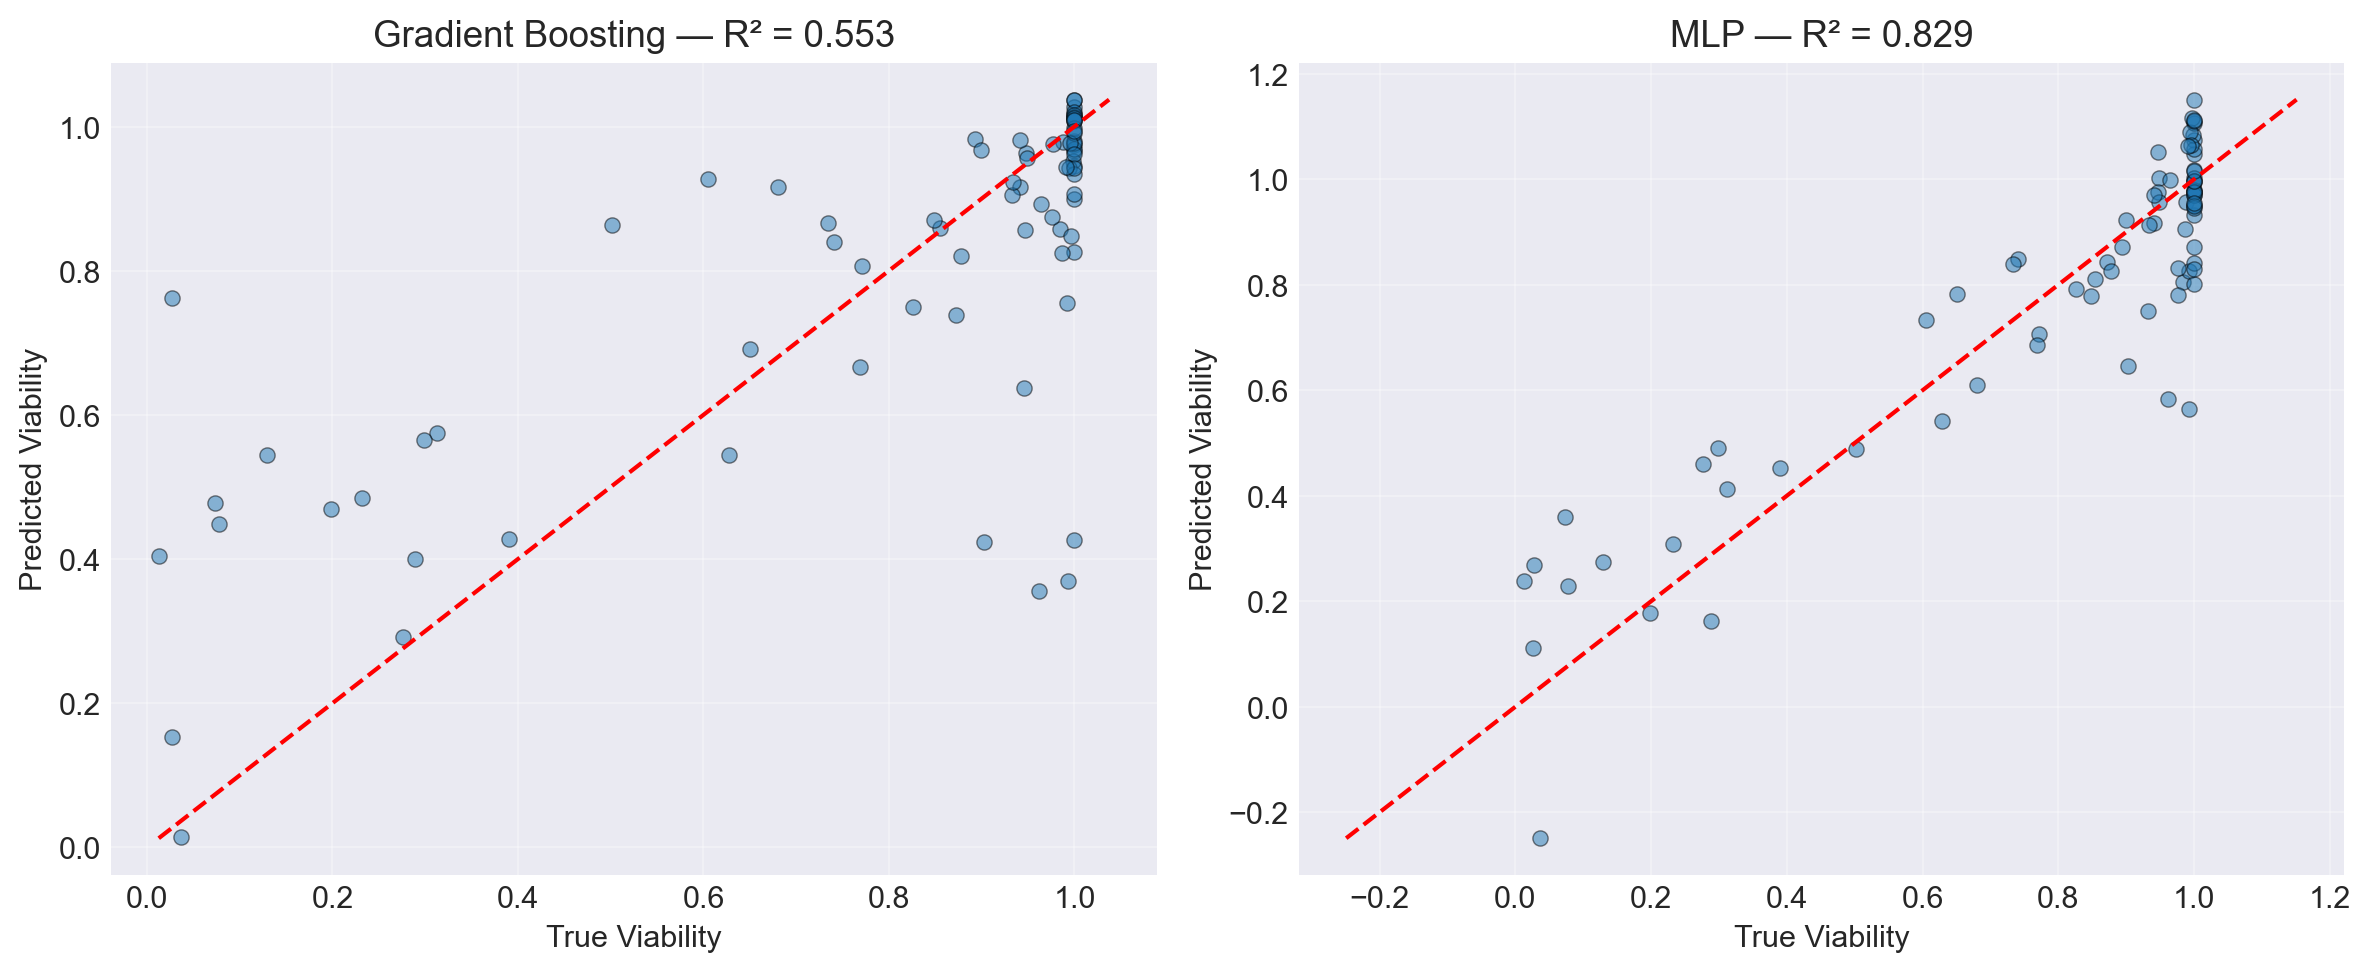

In [347]:
# Predict on test set with both models
Y_gbr_pred = gbr.predict(X_te)
Y_mlp_pred = mlp.predict(X_te_scaled)

# 4. Compute and print R² and RMSE for both
print("GradientBoostingRegressor:")
print("R²:", r2_score(Y_te, Y_gbr_pred))
print("RMSE:", root_mean_squared_error(Y_te, Y_gbr_pred))

print("\nMLPRegressor:")
print("R²:", r2_score(Y_te, Y_mlp_pred))
print("RMSE:", root_mean_squared_error(Y_te, Y_mlp_pred))

# Make a scatter plot: predicted vs actual viability for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, y_pred in [(axes[0], 'Gradient Boosting', Y_gbr_pred),
                          (axes[1], 'MLP', Y_mlp_pred)]:
    ax.scatter(Y_te, y_pred, alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
    lims = [min(Y_te.min(), y_pred.min()), max(Y_te.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_xlabel('True Viability')
    ax.set_ylabel('Predicted Viability')
    ax.set_title(f'{name} — R² = {r2_score(Y_te, y_pred):.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 7.3 — Feature importance and SHAP values

Analyse which parameters the surrogate models consider most important for predicting viability.

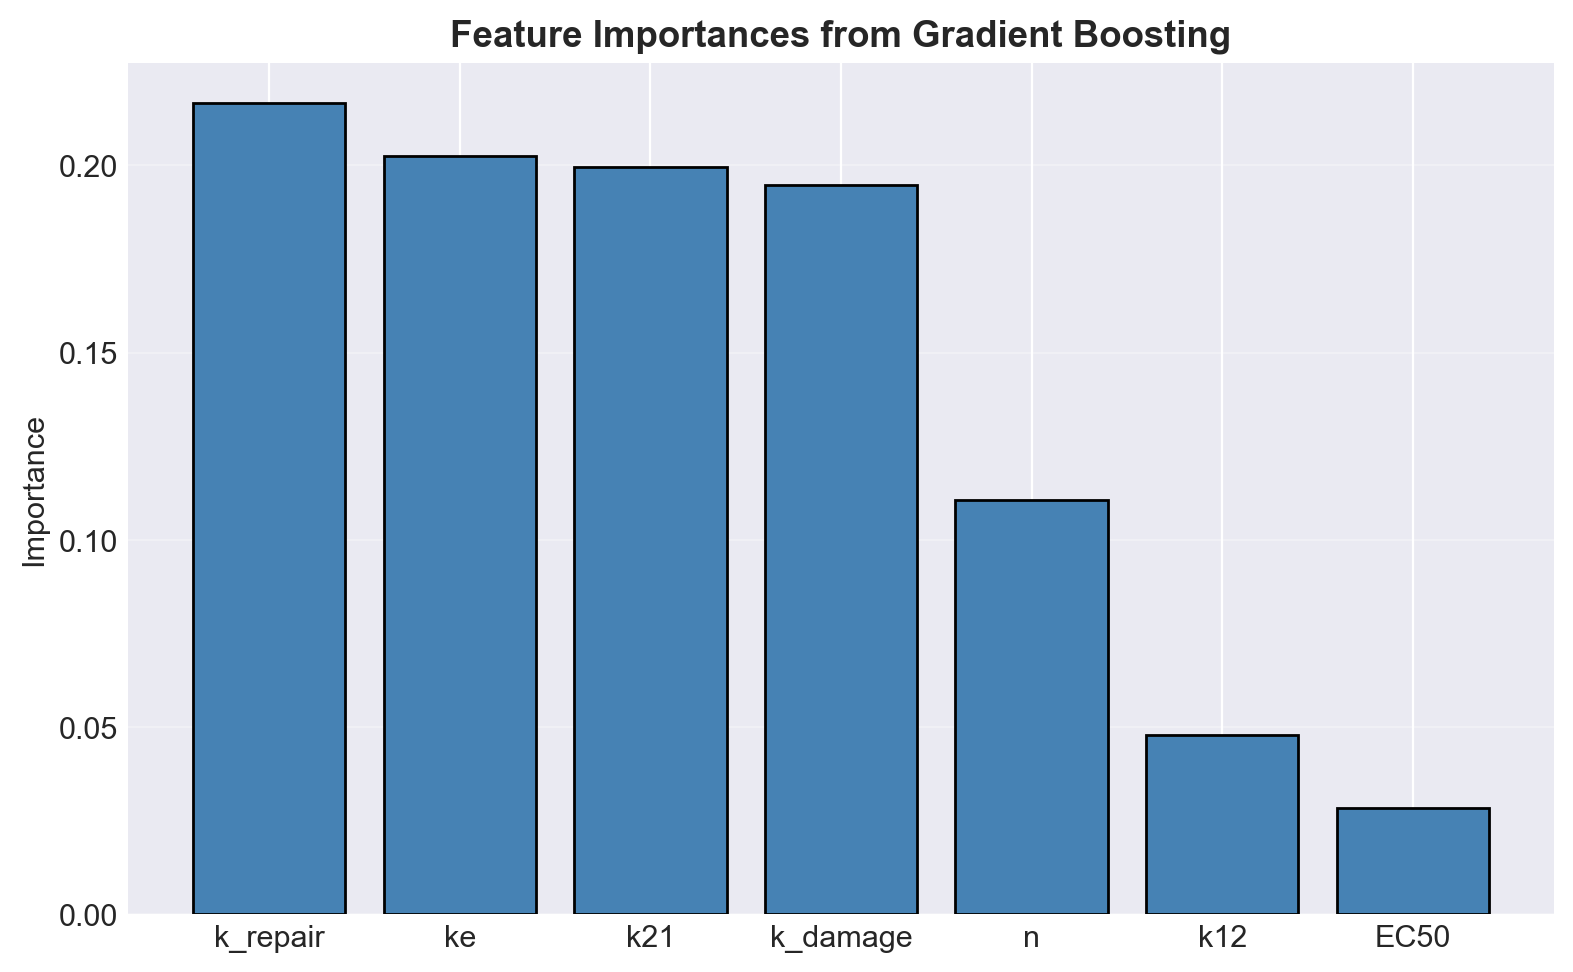


Parameter            μ*          σ Interpretation
-------------------------------------------------------
k_repair         0.9666     0.8756 Important
ke               0.7674     0.9820 Important
k_damage         0.7599     0.8057 Important
k21              0.7483     0.9275 Important
n                0.6982     0.9426 Important
k12              0.6796     0.8411 Important
EC50             0.5684     0.8345 Important


In [367]:
# For the GBR model: extract feature_importances_ and plot as a bar chart
importances = gbr.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
names_short_sorted = [names_short[i] for i in sorted_idx]
importances = importances[sorted_idx]

# import shap
# explainer = shap.Explainer(gbr, X_tr)
# shap_values = explainer(X_te)
# shap.summary_plot(shap_values, X_te, feature_names=names_short)

#    If shap is not available, the feature importances are sufficient.

# Compare the ML feature importance ranking with the Morris screening ranking
# from Section 5. Are they consistent?

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(names_short_sorted, importances, color='steelblue', edgecolor='black')
ax.set_title('Feature Importances from Gradient Boosting', fontweight='bold')
ax.set_ylabel('Importance')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Remind the Morris results for comparison
mu_stars = Si_m['mu_star']
sigmas = Si_m['sigma']
sorted_idx_morris = np.argsort(mu_stars)[::-1]
names_short_morris_sorted = [names_short[i] for i in sorted_idx_morris]
mu_stars_sorted = mu_stars[sorted_idx_morris]
sigmas_sorted = sigmas[sorted_idx_morris]
print(f"\n{'Parameter':<12} {'μ*':>10} {'σ':>10} {'Interpretation'}")
print('-' * 55)
for i, name in enumerate(names_short_morris_sorted):
    mu_star = mu_stars_sorted[i]
    sigma = sigmas_sorted[i]
    if mu_star > 0.1:
        interp = "Important"
    elif mu_star > 0.01:
        interp = "Moderate"
    else:
        interp = "Negligible"
    print(f"{name:<12} {mu_star:>10.4f} {sigma:>10.4f} {interp}")

- ✅ Feature importance tells us which parameters the network has focused the most to predict the results.
- ✅ The order of importance mostly matches the Morris sensitivity screening, only Kdamage and K21 are swapped.

### Task 7.4 — Hybrid model: speed comparison

Replace the forward ODE model with the GBR surrogate inside the parameter estimation loop. Compare wall-clock time for 100 objective evaluations.

This demonstrates the speed advantage of surrogates for tasks like global sensitivity analysis and population-level fitting.

In [381]:
import time

def objective_vitality(log_theta):
    r = residuals(log_theta)
    C1, C2, V = r.reshape(3, -1)
    predicted_viability = V[-1]  # final viability at t=48h
    return (V_obs[-1] - predicted_viability)**2

def surrogate_objective(log_theta):
    """Predict viability using the GBR surrogate instead of the ODE."""
    # Reshape log_theta for sklearn: log_theta.reshape(1, -1)
    log_theta_ = log_theta.reshape(1, -1)
    # Predict viability with gbr.predict(...)
    predicted_viability = gbr.predict(log_theta_)
    # Return (V_obs[-1] - predicted_viability)**2 as a simple scalar
    return (V_obs[-1] - predicted_viability)**2


# Time 100 evaluations of the ODE-based objective
start_time_ode = time.time()
l_ode = 0.
for _ in range(100):
    l_ode += objective_vitality(theta_true)  # or any other parameter set
end_time_ode = time.time()
time_ode = end_time_ode - start_time_ode
l_ode = l_ode / 100  # average ODE loss over 100 evaluations

# Time 100 evaluations of the surrogate-based objective
start_time_surrogate = time.time()
l_surrogate = 0.
for _ in range(100):
    l_surrogate += surrogate_objective(theta_true)  # same parameter set for fair comparison
end_time_surrogate = time.time()
time_surrogate = end_time_surrogate - start_time_surrogate
l_surrogate = float(l_surrogate / 100)  # average surrogate loss over 100 evaluations

# Print the speedup factor
print(f"Time for ODE-based objective (100 evals): {time_ode:.4f} seconds with average loss {l_ode:.4f}")
print(f"Time for surrogate-based objective (100 evals): {time_surrogate:.4f} seconds with average loss {l_surrogate:.4f}")
print(f"Speedup factor: {time_ode / time_surrogate:.2f}x")

# The lower ML loss indicates that the ML model is able to navigate the parameter space more intelligently,
# While local 

Time for ODE-based objective (100 evals): 2.8006 seconds with average loss 3.9341
Time for surrogate-based objective (100 evals): 0.0181 seconds with average loss 0.0653
Speedup factor: 154.85x


---
## Summary

You have now completed the full pipeline that this role requires:

| Section | What you built | Job responsibility it maps to |
|---------|---------------|-------------------------------|
| 1 | Two-compartment PK model | Construct sub-models |
| 2 | Coupled PK-toxicity system | Connect sub-models with defined interfaces |
| 3 | Local parameter estimation | Parametrise biological models |
| 4 | Global optimisation | Handle non-convex landscapes at scale |
| 5 | Morris screening & local sensitivity | Sensitivity analysis of mechanistic models |
| 6 | FIM & identifiability analysis | Assess what can be estimated from data |
| 7 | ML surrogates & SHAP | Incorporate interpretable ML; accelerate computation |

**Next steps in the actual role** would include: scaling to 10+ coupled sub-models, implementing the model registry pattern for automated execution ordering, parallelising across HPC clusters with Slurm, and using the FIM for optimal experimental design.

---
*End of onboarding notebook.*